In [17]:
# Step 2: EEG decoding


# GAO decoding analysis
# 
import pandas as pd
import glob
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, roc_auc_score
import scipy.stats as stats
from scipy.interpolate import interp1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from joblib import Parallel, delayed
from sklearn.base import clone
from mne.time_frequency import tfr_array_morlet
import pingouin as pg

from utils.gao_functions import red_color, blue_color, red_palette, blue_palette, purple_color, purple_palette, lightblue_color, lightred_color, lightblue_palette, lightred_palette, calculate_vtc, calculate_BF, plot_BF_subplot, get_image_cat, calculate_COCE_zone, make_timecourse_plot, make_Gabor_timecourse_plot

# sm = SMOTE(random_state=42)
# X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# import numpy as np
# from scipy.io import loadmat
# import pandas as pd
import os
os.environ["R_HOME"] = r"/Library/Frameworks/R.framework/Resources"

from rpy2.robjects import r
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
import matplotlib.pyplot as plt
import seaborn as sns

bf_package=importr('BayesFactor')


# rus = RandomUnderSampler(random_state=42)

import matplotlib.pyplot as plt
from matplotlib import colors

import mne
# from mne.datasets import sample
from mne.decoding import (
    SlidingEstimator
)

# clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced'), )

clf = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(store_covariance=True))
experiment_name = 'GAO'


from included_subs import subs

# CHECK UD/LR MAPPING _ DO NAMES MATCH NUMBERS?
dot_direction_map = {'UD':41, 'LR':42}
cat_map = {'vehicle':31, 'food': 32}

train_image_triggers = [11, 12] #vehicle, food
train_gabor_triggers = [21, 22] #Vertical, horizontal

test_image_triggers = [31, 32]# vehicle, food
test_gabor_triggers = [41, 42]# Vertical, horizontal

# smooth_VTC = 'yes'
# if smooth_VTC == 'yes':
#     vtc_variable = 'vtc_smooth_detrended'
# elif smooth_VTC == 'no':
#     vtc_variable = 'vtc_detrended'
# else:
#     print('smooth_VTC must be either yes or no!')
font_sz = 18
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.labelsize'] = font_sz
plt.rcParams['ytick.labelsize'] = font_sz
plt.rcParams['axes.titlesize'] = font_sz
plt.rcParams['legend.fontsize'] = font_sz - 4

figdir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/figures/'

exclude_ppt_channels = 'yes'
exclude_channels = {
    '01':['TP9','Fp1','Fp2','P3'],
    '02':['CP6','T7','TP9','Fp1','Fp2'],
    '03':['F4','TP9','Fp1','Fp2'],
    '04':['TP9','Fp1','Fp2'],
    '05':['FC5','TP9','Fp1','Fp2'],
    '06':['TP9','Fp1','Fp2'],
    '07':['TP9','Fp1','Fp2'],
    '08':['T8', 'CP2', 'FT9', 'T7', 'TP9','Fp1','Fp2'],
    '09':['TP9','Fp1','Fp2'],
    '10':['T8', 'TP9','Fp1','Fp2'],
    '11':['C3', 'TP9','Fp1','Fp2'],
    '12':['TP9','Fp1','Fp2'],
    '13':['TP9','Fp1','Fp2'],
    '14':['T7','T8','FC2','P7','Cz','CP2', 'TP9','Fp1','Fp2'],
    '15':['TP9','Fp1','Fp2'],
    '16':['TP9','Fp1','Fp2'],
    '17':['TP9','Fp1','Fp2','T7','T8'],
    '18':['TP9','Fp1','Fp2','C4','FC1'],
    '19':['TP9','Fp1','Fp2','FT10','FT9','T7','FC6'],
    '20':['TP9','Fp1','Fp2'],
    '21':['TP9','Fp1','Fp2','F3','F4','T7'],
    '22':['TP9','Fp1','Fp2','FT10'],
    '23':['TP9','Fp1','Fp2'],
    '24':['TP9','Fp1','Fp2','FT10'],
    '25':['TP9','Fp1','Fp2','T7'],
    '26':['TP9','Fp1','Fp2'],
    '27':['TP9','Fp1','Fp2'],
    '28':['TP9','Fp1','Fp2','F3'],
    '29':['TP9','Fp1','Fp2','T8']
}


cacs_montage = mne.channels.read_custom_montage('/Users/annacorriveau/Downloads/actiCap_snap_CACS_CAS/actiCap_slim_for actiChamp_Plus/CACS-32/CACS-32_NO_REF.bvef')
# print(cacs_montage.ch_names)
all_channels = cacs_montage.ch_names
# all_channels.remove('GND')
# print(all_channels)

In [19]:
pwd


'/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts'

In [260]:
# Use performance on infrequent trials as label for in-zone vs out-of-zone


FWHM = 4

for sub in subs:
    behav_dir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/raw_data/raw_behavioral/' + sub + '/'
    # eeg_dir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'
    eeg_dir = '/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'

    behav_files = glob.glob(behav_dir + sub + '*.csv')
    print(behav_files)
    if len(behav_files)==1:
        behav_file = pd.read_csv(behav_files[0])
    else:
        print('Multiple (or zero) behavioral files found for subject ' + sub)

    behav_file = behav_file[behav_file['task'].notna()]
    behav_file = behav_file[~behav_file['task'].str.contains('practice')]
    dot_training_trials = behav_file[behav_file['task']=='train_dots']
    cat_training_trials = behav_file[behav_file['task']=='train_image_cat']

    cpt_trials = behav_file[behav_file['task'].str.contains('cpt')]

    # print(cpt_trials.task)
    cpt_trials_vtc = calculate_COCE_zone(cpt_trials, FWHM)

    behav_join_DF = pd.merge(behav_file, cpt_trials_vtc, left_index=True, right_index=True, how='outer')
    # behav_join_DF.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_behav_DF_withVTC.csv')
    cpt_trials_vtc.to_csv('/Users/annacorriveau/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_CPT_DF_withVTC_andCOCE.csv')


    # Compare performance in and out of the zone
    in_zone = cpt_trials_vtc[cpt_trials_vtc['COCE_zone']==1]
    out_zone = cpt_trials_vtc[cpt_trials_vtc['COCE_zone']==0]


    # Load preprocessed EEG data--remove artifacts
    epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs=epochs_pre.copy().resample(200, npad='auto')
    # epochs_resampled = epochs.copy().resample(100, npad='auto')
    events = pd.read_csv(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_events.tsv', header=0, sep='\t')
    # Drop TP9
    if exclude_ppt_channels == 'yes':
        epochs.drop_channels(exclude_channels[sub])
    else:
        epochs.drop_channels(['TP9','Fp1','Fp2'])

    artifacts = np.load(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_rejection_flags.npy')
    print(artifacts)

    epochs.drop(artifacts)
    events = events[~artifacts]


    behav_plusmem = behav_join_DF.copy()
    behav_join_DF = behav_join_DF[~behav_join_DF['task_x'].str.contains('memory')]
    behav_join_DF = behav_join_DF.reset_index(drop=True)
    behav_join_DF = behav_join_DF[~artifacts]



    x_data = epochs.get_data(picks='eeg')

    x_data_eyegaze = epochs.get_data(picks=['eyegaze'])
    x_data_pupil = epochs.get_data(picks=['pupil'])
    x_data_eog = epochs.get_data(picks=['eog'])

    # Get labeled trials
    x_train_image = x_data[events.value.isin(train_image_triggers)]
    x_test_image = x_data[events.value.isin(test_image_triggers)]
    x_train_gabor = x_data[events.value.isin(train_gabor_triggers)]
    x_test_gabor = x_data[events.value.isin(test_gabor_triggers)]

    y_train_image = events[events.value.isin(train_image_triggers)].value
    y_test_image = events[events.value.isin(test_image_triggers)].value
    y_train_gabor = events[events.value.isin(train_gabor_triggers)].value
    y_test_gabor = events[events.value.isin(test_gabor_triggers)].value

    included_trials_test_image = np.in1d(events['value'], test_image_triggers)
    included_trials_test_gabor = np.in1d(events['value'], test_gabor_triggers)

    behav_join_DF['image_cat'] = behav_join_DF['image_x'].apply(get_image_cat)
    behav_join_DF['cat_numeric'] = behav_join_DF['image_cat'].map(cat_map)
    behav_join_DF['direction_numeric'] = behav_join_DF['direction_x'].map(dot_direction_map)

    behav_test_image = behav_join_DF[included_trials_test_image]
    behav_test_image_irrel = behav_join_DF[included_trials_test_gabor]


    
    x_test_image_inzone = x_test_image[behav_test_image["COCE_zone"]==1]
    x_test_image_outzone = x_test_image[behav_test_image["COCE_zone"]==0]
    behav_test_image_inzone = behav_test_image[behav_test_image["COCE_zone"]==1]
    behav_test_image_outzone = behav_test_image[behav_test_image["COCE_zone"]==0]
    
    x_test_gabor_inzone = x_test_gabor[behav_test_image_irrel["COCE_zone"]==1]
    x_test_gabor_outzone = x_test_gabor[behav_test_image_irrel["COCE_zone"]==0]
    behav_test_gabor_inzone = behav_test_image_irrel[behav_test_image_irrel["COCE_zone"]==1]
    behav_test_gabor_outzone = behav_test_image_irrel[behav_test_image_irrel["COCE_zone"]==0]


# Train classifier


    time_decod_image = SlidingEstimator(clf, n_jobs=None, scoring="roc_auc", verbose=True)
    time_decod_image.fit(x_train_image, y_train_image)

    # y_pproba_imrel = time_decod_image.predict_proba(x_test_image)
    # y_vals_imrel = y_test_image
    # auc_imrel = [roc_auc_score(y_vals_imrel, y_pproba_imrel[:,col,1]) for col in np.arange(0,y_pproba_imrel.shape[1])]
    # pd.DataFrame(auc_imrel).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/' + sub + '_relevant_AUC_COCE.csv', index=None, header=None)

    y_pproba_image_inzone = time_decod_image.predict_proba(x_test_image_inzone)
    # predictions_image_inzone = np.argmax(y_pproba_image_inzone, axis=2)
# acc_image_inzone = accuracy_score(behav_test_image_inzone['cat_numeric'], predictions_image_inzone)
    # print(predictions_image_inzone.shape)
    # tbyt_acc_image_inzone = [(col == behav_test_image_inzone['cat_numeric']-31) for col in zip(*predictions_image_inzone)]
    # acc_image_inzone = accuracy_score(behav_test_image_inzone['cat_numeric'], predictions_image_inzone)
    # tbyt_acc_image_inzone = (predictions_image_inzone == behav_test_image_inzone['cat_numeric'])

    # error
    tc_avg_pproba_image_inzone=np.mean(y_pproba_image_inzone, axis=1)
    trial_wise_pproba_image_inzone = tc_avg_pproba_image_inzone[np.arange(0,len(np.array(behav_test_image_inzone['cat_numeric']-31))), np.array(behav_test_image_inzone['cat_numeric']-31).astype(int)]
    pd.DataFrame(trial_wise_pproba_image_inzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_in-zone_relevant_trialwise_probs.csv', index=None, header=None)

    auc_image_inzone = [roc_auc_score(behav_test_image_inzone['cat_numeric'], y_pproba_image_inzone[:,col,1]) for col in np.arange(0,y_pproba_image_inzone.shape[1])]
    pd.DataFrame(auc_image_inzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_in-zone_relevant_COCE_AUC.csv', index=None, header=None)

    y_pproba_image_outzone = time_decod_image.predict_proba(x_test_image_outzone)
    tc_avg_pproba_image_outzone=np.mean(y_pproba_image_outzone, axis=1)
    trial_wise_pproba_image_outzone = tc_avg_pproba_image_outzone[np.arange(0,len(np.array(behav_test_image_outzone['cat_numeric']-31))), np.array(behav_test_image_outzone['cat_numeric']-31).astype(int)]
    pd.DataFrame(trial_wise_pproba_image_outzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_out-zone_relevant_trialwise_probs.csv', index=None, header=None)

    auc_image_outzone = [roc_auc_score(behav_test_image_outzone['cat_numeric'], y_pproba_image_outzone[:,col,1]) for col in np.arange(0,y_pproba_image_outzone.shape[1])]
    pd.DataFrame(auc_image_outzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_out-zone_relevant_COCE_AUC.csv', index=None, header=None)


    y_pproba_gabor_inzone = time_decod_image.predict_proba(x_test_gabor_inzone)
    tc_avg_pproba_gabor_inzone=np.mean(y_pproba_gabor_inzone, axis=1)
    trial_wise_pproba_gabor_inzone = tc_avg_pproba_gabor_inzone[np.arange(0,len(np.array(behav_test_gabor_inzone['cat_numeric']-31))), np.array(behav_test_gabor_inzone['cat_numeric']-31).astype(int)]
    pd.DataFrame(trial_wise_pproba_gabor_inzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_in-zone_irrelevant_trialwise_probs.csv', index=None, header=None)

    auc_gabor_inzone = [roc_auc_score(behav_test_gabor_inzone['cat_numeric'], y_pproba_gabor_inzone[:,col,1]) for col in np.arange(0,y_pproba_gabor_inzone.shape[1])]
    pd.DataFrame(auc_gabor_inzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_in-zone_irrelevant_COCE_AUC.csv', index=None, header=None)


    y_pproba_gabor_outzone = time_decod_image.predict_proba(x_test_gabor_outzone)
    tc_avg_pproba_gabor_outzone=np.mean(y_pproba_gabor_outzone, axis=1)
    trial_wise_pproba_gabor_outzone = tc_avg_pproba_gabor_outzone[np.arange(0,len(np.array(behav_test_gabor_outzone['cat_numeric']-31))), np.array(behav_test_gabor_outzone['cat_numeric']-31).astype(int)]
    pd.DataFrame(trial_wise_pproba_gabor_outzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_out-zone_irrelevant_trialwise_probs.csv', index=None, header=None)

    auc_gabor_outzone = [roc_auc_score(behav_test_gabor_outzone['cat_numeric'], y_pproba_gabor_outzone[:,col,1]) for col in np.arange(0,y_pproba_gabor_outzone.shape[1])]
    pd.DataFrame(auc_gabor_outzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_out-zone_irrelevant_COCE_AUC.csv', index=None, header=None)






    # Gabor Classifier
    time_decod_gabor = SlidingEstimator(clf, n_jobs=None, scoring="roc_auc", verbose=True)
    time_decod_gabor.fit(x_train_gabor, y_train_gabor)

    # y_pproba_imrel = time_decod_image.predict_proba(x_test_image)
    # y_vals_imrel = y_test_image
    # auc_imrel = [roc_auc_score(y_vals_imrel, y_pproba_imrel[:,col,1]) for col in np.arange(0,y_pproba_imrel.shape[1])]
    # pd.DataFrame(auc_imrel).to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/' + sub + '_relevant_AUC_COCE.csv', index=None, header=None)

    y_pproba_gabor_inzone = time_decod_gabor.predict_proba(x_test_gabor_inzone)
    auc_gabor_inzone = [roc_auc_score(behav_test_gabor_inzone['direction_numeric'], y_pproba_gabor_inzone[:,col,1]) for col in np.arange(0,y_pproba_gabor_inzone.shape[1])]
    pd.DataFrame(auc_gabor_inzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/gabor_decoding/' + sub + '_in-zone_relevant_COCE_AUC.csv', index=None, header=None)


    y_pproba_gabor_outzone = time_decod_gabor.predict_proba(x_test_gabor_outzone)
    auc_gabor_outzone = [roc_auc_score(behav_test_gabor_outzone['direction_numeric'], y_pproba_gabor_outzone[:,col,1]) for col in np.arange(0,y_pproba_gabor_outzone.shape[1])]
    pd.DataFrame(auc_gabor_outzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/gabor_decoding/' + sub + '_out-zone_relevant_COCE_AUC.csv', index=None, header=None)


    y_pproba_image_inzone = time_decod_gabor.predict_proba(x_test_image_inzone)
    auc_image_inzone = [roc_auc_score(behav_test_image_inzone['direction_numeric'], y_pproba_image_inzone[:,col,1]) for col in np.arange(0,y_pproba_image_inzone.shape[1])]
    pd.DataFrame(auc_image_inzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/gabor_decoding/' + sub + '_in-zone_irrelevant_COCE_AUC.csv', index=None, header=None)


    y_pproba_image_outzone = time_decod_gabor.predict_proba(x_test_image_outzone)
    auc_image_outzone = [roc_auc_score(behav_test_image_outzone['direction_numeric'], y_pproba_image_outzone[:,col,1]) for col in np.arange(0,y_pproba_image_outzone.shape[1])]
    pd.DataFrame(auc_image_outzone).to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/gabor_decoding/' + sub + '_out-zone_irrelevant_COCE_AUC.csv', index=None, header=None)



['/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/raw_data/raw_behavioral/01/01_data_2025_Oct_29_1041_5.csv']
0.05140345076172896
0.05909256401758137


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:350: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df['COCE_zone'] = np.nan
/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:351: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataF

0.05101376202245117
0.04883439089050293
Reading /Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif ...


/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/3749556352.py:39: RuntimeWarning: This filename (/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')


    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False  True ... False  True False]
Dropped 2183 epochs: 2, 6, 7, 8, 9, 11, 15, 19, 20, 21, 22, 25, 28, 29, 31, 33, 35, 36, 38, 39, 40, 41, 42, 44, 46, 47, 49, 50, 54, 55, 57, 59, 60, 64, 65, 69, 73, 75, 77, 80, 84, 85, 89, 93, 96, 99, 101, 106, 108, 111, 113, 114, 118, 122, 125, 129, 130, 133, 136, 141, 142, 144, 147, 149, 151, 153, 156, 157, 158, 161, 165, 168, 170, 172, 173, 176, 177, 179, 181, 183, 186, 188, 191, 192, 194, 197, 200, 204, 205, 207, 208, 210, 213, 216, 219, 222, 228, 230, 233, 234, 235, 236, 239, 240, 241, 245, 246, 248, 251, 252, 255, 256, 260, 261, 262, 264, 266, 269, 271, 272, 273, 276, 279, 283, 285, 287, 290, 291, 293, 294, 295, 297, 298, 300, 301, 302, 303, 304, 305, 307, 310, 312, 314, 316, 318, 319, 321, 322, 324, 325, 

...

  0%|          | Fitting SlidingEstimator : 0/190 [00:00<?,       ?it/s]

  0%|          | Transforming SlidingEstimator : 0/190 [00:00<?,       ?it/s]

  0%|          | Transforming SlidingEstimator : 0/190 [00:00<?,       ?it/s]

  0%|          | Transforming SlidingEstimator : 0/190 [00:00<?,       ?it/s]

  0%|          | Transforming SlidingEstimator : 0/190 [00:00<?,       ?it/s]

(127, 190)
3601    32.0
3602    32.0
3604    31.0
3633    32.0
3635    31.0
        ... 
5242    32.0
5263    31.0
5311    32.0
5313    31.0
5361    31.0
Name: cat_numeric, Length: 127, dtype: float64
[3601     True
3602    False
3604     True
3633    False
3635     True
        ...  
5242     True
5263     True
5311     True
5313     True
5361    False
Name: cat_numeric, Length: 127, dtype: bool, 3601     True
3602    False
3604    False
3633     True
3635     True
        ...  
5242    False
5263    False
5311     True
5313    False
5361    False
Name: cat_numeric, Length: 127, dtype: bool, 3601     True
3602    False
3604    False
3633    False
3635     True
        ...  
5242    False
5263     True
5311     True
5313    False
5361     True
Name: cat_numeric, Length: 127, dtype: bool, 3601    False
3602    False
3604     True
3633    False
3635    False
        ...  
5242    False
5263    False
5311     True
5313    False
5361    False
Name: cat_numeric, Length: 127, dtype: bool, 36

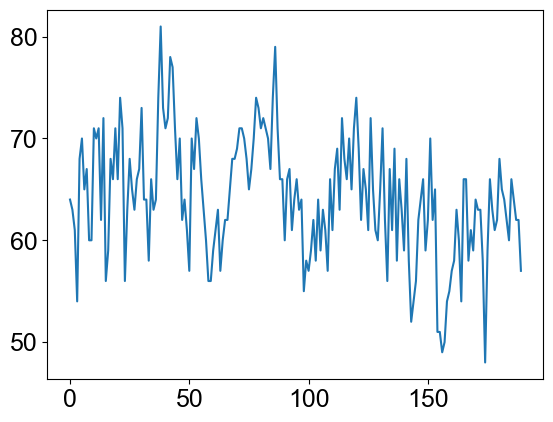

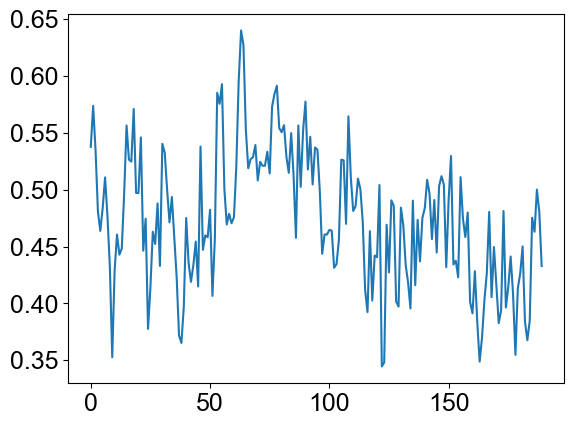

In [200]:
# acc_image_inzone
# tbyt_
predictions_image_inzone = np.argmax(y_pproba_image_inzone, axis=2)
# acc_image_inzone = accuracy_score(behav_test_image_inzone['cat_numeric'], predictions_image_inzone)
print(predictions_image_inzone.shape)
tbyt_acc_image_inzone = [(col == behav_test_image_inzone['cat_numeric']-31) for col in zip(*predictions_image_inzone)]
print(behav_test_image_inzone['cat_numeric'])
print(tbyt_acc_image_inzone)
# print(sum(tbyt_acc_image_inzone))
# y_pproba_image_inzone
tc = []
for item in tbyt_acc_image_inzone:
    print(np.sum(item))
    tc.append(np.sum(item))
plt.plot(tc)
plt.show()


plt.plot(auc_image_inzone)
plt.show()

/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val          CI95%   cohen-d  BF10  \
T-test -1.146299   24   two-sided  0.262972  [-0.03, 0.01]  0.302715  0.38   

           power  
T-test  0.306492  
irrelevant
pre-correct
0.5319048214359909
0.03324380959964099
irrelevant
pre-lapse
0.5432712544251669
0.040022529458562064
0.38
['$\\mathrm{BF}_{10}$ = 0.38']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

irrelevant
pre-correct vs. irrelevant
pre-lapse: $\mathrm{BF}_{10}$ = 0.38


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


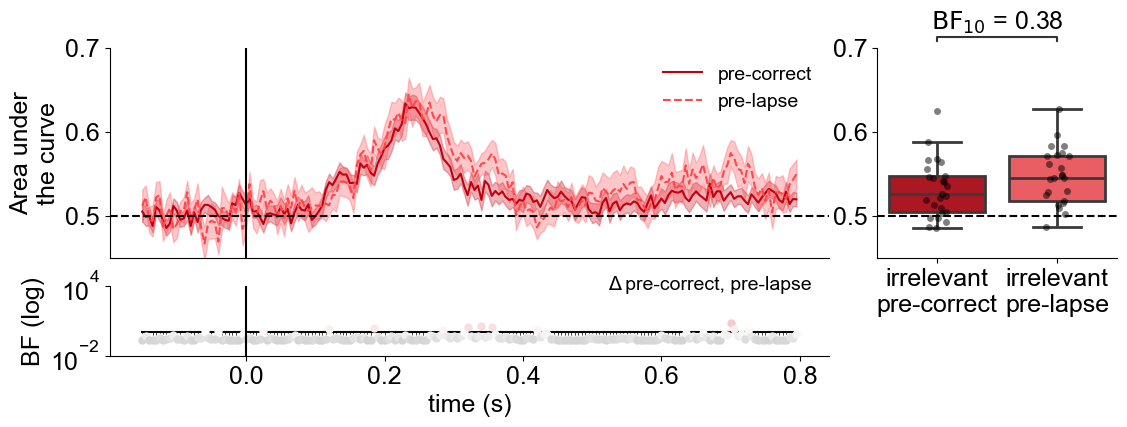

               T  dof alternative     p-val         CI95%  cohen-d     BF10  \
T-test  4.404988   24   two-sided  0.000189  [0.02, 0.05]  0.79016  152.209   

          power  
T-test  0.96625  
relevant
pre-correct
0.5605252282230528
0.0276168411746392
relevant
pre-lapse
0.5294534916014877
0.046970768285641624
152.209
['$\\mathrm{BF}_{10}$ = 152.21']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

relevant
pre-correct vs. relevant
pre-lapse: $\mathrm{BF}_{10}$ = 152.21


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


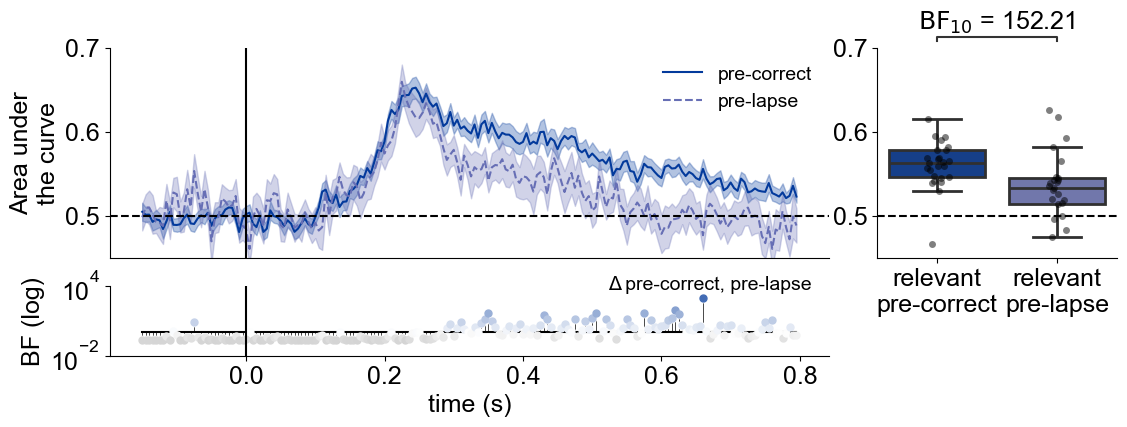

In [20]:
if 'epochs' not in vars():
    epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs = epochs_pre.copy().resample(200)
x_axis = epochs.times

    
in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()

in_rel_mean = []
out_rel_mean = []
in_irrel_mean = []
out_irrel_mean = []
# subs=['01','02','03','05','06','07','08','10','12','13','14','15','17','18','20','21','22','23','24','25','26','27','28','29']
# subs=['27']
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + s + '_in-zone_relevant_COCE_AUC.csv', header=None)
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_acc.T], axis=0)
    in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))

    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + s + '_out-zone_relevant_COCE_AUC.csv', header=None)
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_acc.T], axis=0)
    out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))


    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + s + '_in-zone_irrelevant_COCE_AUC.csv', header=None)
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_acc.T], axis=0)
    in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))

    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + s + '_out-zone_irrelevant_COCE_AUC.csv', header=None)
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_acc.T], axis=0)
    out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))

mean_in_rel_acc = np.mean(in_rel_acc_df, axis=0)
mean_out_rel_acc = np.mean(out_rel_acc_df, axis=0)
mean_in_irrel_acc = np.mean(in_irrel_acc_df, axis=0)
mean_out_irrel_acc = np.mean(out_irrel_acc_df, axis=0)


SE_in_rel = stats.sem(in_rel_acc_df, axis=0)
SE_in_irrel = stats.sem(in_irrel_acc_df, axis=0)
SE_out_rel = stats.sem(out_rel_acc_df, axis=0)
SE_out_irrel = stats.sem(out_irrel_acc_df, axis=0)



bf_diff_inout = calculate_BF(in_rel_acc_df, out_rel_acc_df)

bf_diff_inoutirrel = calculate_BF(in_irrel_acc_df, out_irrel_acc_df)


plot_dict = {
    'tc1': mean_in_irrel_acc, 
    'tc1_label': "pre-correct",
    'tc2': mean_out_irrel_acc,
    'tc2_label': "pre-lapse",
    'tc1_SE': SE_in_irrel,
    'tc2_SE': SE_out_irrel,
    'tc1_color': red_color,
    'tc2_color': lightred_color,
    'tc2_linestyle':'--',
    'bar1': in_irrel_mean,
    'bar1_label': 'irrelevant\npre-correct',
    'bar2_label': 'irrelevant\npre-lapse',
    'bar2': out_irrel_mean,
    'BF': bf_diff_inoutirrel,
    'BF_palette': red_palette,
    'BF_title':"\u0394 pre-correct, pre-lapse",
    'BF_top':4,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig4B_image_irrel_inout_onsetlocked.png'
}


make_timecourse_plot(plot_dict)


# plot_dict = {
#     'tc1': mean_in_irrel_acc, 
#     'tc1_label': "pre-correct",
#     'tc2': mean_out_irrel_acc,
#     'tc2_label': "pre-lapse",
#     'tc1_SE': SE_in_irrel,
#     'tc2_SE': SE_out_irrel,
#     'tc1_color': red_color,
#     'tc2_color': lightred_color,
#     'tc2_linestyle':'--',
#     'bar1': in_irrel_mean,
#     'bar1_label': 'irrelevant\npre-correct',
#     'bar2_label': 'irrelevant\npre-lapse',
#     'bar2': out_irrel_mean,
#     'BF': bf_diff_inoutirrel,
#     'BF_palette': red_palette,
#     'BF_title':"\u0394 pre-correct, pre-lapse",
#     'BF_top':3,
#     'x_axis': epochs.times,
#     'save_name':figdir + 'Fig4B_image_irrel_inout_onsetlocked.svg'
# }


# make_timecourse_plot(plot_dict)


plot_dict_rel = {
    'tc1': mean_in_rel_acc, 
    'tc1_label': "pre-correct",
    'tc2': mean_out_rel_acc,
    'tc2_label': "pre-lapse",
    'tc1_SE': SE_in_rel,
    'tc2_SE': SE_out_rel,
    'tc1_color': blue_color,
    'tc2_color': lightblue_color,
    'tc2_linestyle':'--',
    'bar1': in_rel_mean,
    'bar1_label': 'relevant\npre-correct',
    'bar2_label': 'relevant\npre-lapse',
    'bar2': out_rel_mean,
    'BF': bf_diff_inout,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 pre-correct, pre-lapse",
    'BF_top':4,
    'x_axis': epochs.times,
    'save_name':figdir + 'Fig4A_image_rel_inout_onsetlocked.png'
}

make_timecourse_plot(plot_dict_rel)


# plot_dict_rel = {
#     'tc1': mean_in_rel_acc, 
#     'tc1_label': "pre-correct",
#     'tc2': mean_out_rel_acc,
#     'tc2_label': "pre-lapse",
#     'tc1_SE': SE_in_rel,
#     'tc2_SE': SE_out_rel,
#     'tc1_color': blue_color,
#     'tc2_color': lightblue_color,
#     'tc2_linestyle':'--',
#     'bar1': in_rel_mean,
#     'bar1_label': 'relevant\npre-correct',
#     'bar2_label': 'relevant\npre-lapse',
#     'bar2': out_rel_mean,
#     'BF': bf_diff_inout,
#     'BF_palette': blue_palette,
#     'BF_title':"\u0394 pre-correct, pre-lapse",
#     'BF_top':3,
#     'x_axis': epochs.times,
#     'save_name':figdir + 'Fig4A_image_rel_inout_onsetlocked.svg'
# }

# make_timecourse_plot(plot_dict_rel)

In [90]:
# Make DF to run GLM 
in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()


trial_tps = epochs.times>0
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + s + '_in-zone_relevant_COCE_AUC.csv', header=None)
    in_rel_df = pd.DataFrame({'mean_decoding':[np.mean(in_rel_acc[trial_tps])], 'relevance':'rel', 'zone':'in' })
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_df], axis=0)
    # in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))

    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + s + '_out-zone_relevant_COCE_AUC.csv', header=None)
    out_rel_df = pd.DataFrame({'mean_decoding':[np.mean(out_rel_acc[trial_tps])], 'relevance':'rel', 'zone':'out' })
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_df], axis=0)
    # out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))

    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + s + '_in-zone_irrelevant_COCE_AUC.csv', header=None)
    in_irrel_df = pd.DataFrame({'mean_decoding':[np.mean(in_irrel_acc[trial_tps])], 'relevance':'irrel', 'zone':'in' })
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_df], axis=0)

    # in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))
    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + s + '_out-zone_irrelevant_COCE_AUC.csv', header=None)
    out_irrel_df = pd.DataFrame({'mean_decoding':[np.mean(out_irrel_acc[trial_tps])], 'relevance':'irrel', 'zone':'out' })
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_df], axis=0)
    # out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))

# in_rel_acc_df['relevance'] = 'rel'
# out_rel_acc_df['relevance'] = 'rel'
# in_irrel_acc_df['relevance'] = 'irrel'
# out_irrel_acc_df['relevance'] = 'irrel'

# in_rel_acc_df['zone'] = 'in'
# out_rel_acc_df['zone'] = 'out'
# in_irrel_acc_df['zone'] = 'in'
# out_irrel_acc_df['zone'] = 'out'

frames = [in_rel_acc_df, out_rel_acc_df, in_irrel_acc_df, out_irrel_acc_df]
DF = pd.concat(frames, ignore_index=True)
DF.to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/DF_relevance_by_zone_GLM.csv', index=None)

In [88]:
in_irrel_df['mean'] = 'test1'
out_irrel_df

,mean_decoding,relevance,zone
0,0.548442,rel,in


In [73]:
in_rel_acc['mean_decoding'] = np.mean(in_rel_acc[trial_tps])
in_rel_acc['mean_decoding']

0      0.594414
1      0.594414
2      0.594414
3      0.594414
4      0.594414
         ...   
185    0.594414
186    0.594414
187    0.594414
188    0.594414
189    0.594414
Name: mean_decoding, Length: 190, dtype: float64

/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test -0.566384   24   two-sided  0.576392  [-0.02, 0.01]  0.155574  0.244   

           power  
T-test  0.115989  
irrelevant
pre-correct
0.5040103329195861
0.016663051532345964
irrelevant
pre-lapse
0.5079666471693424
0.031048674174546747
0.244
['$\\mathrm{BF}_{10}$ = 0.24']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

irrelevant
pre-correct vs. irrelevant
pre-lapse: $\mathrm{BF}_{10}$ = 0.24


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


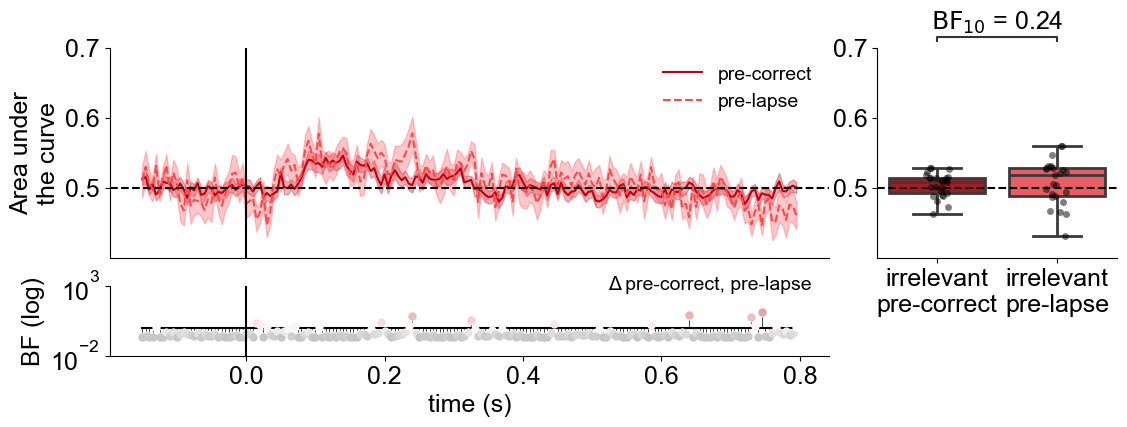

               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test  1.010817   24   two-sided  0.322187  [-0.01, 0.02]  0.259727  0.334   

           power  
T-test  0.238604  
relevant
pre-correct
0.5161179359338552
0.019560918552352053
relevant
pre-lapse
0.5091793903876595
0.031426650194476595
0.334
['$\\mathrm{BF}_{10}$ = 0.33']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

relevant
pre-correct vs. relevant
pre-lapse: $\mathrm{BF}_{10}$ = 0.33


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


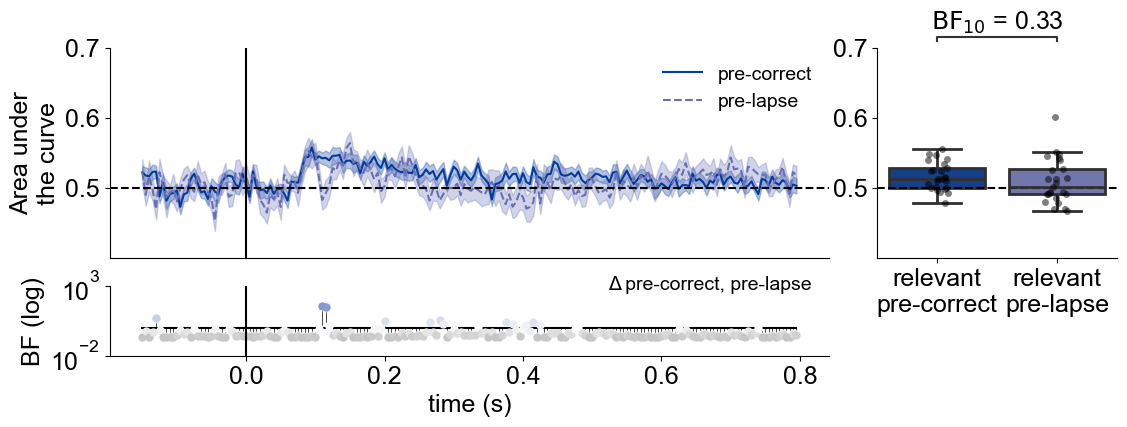

In [93]:
if 'epochs' not in vars():
    epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs = epochs_pre.copy().resample(200)
x_axis = epochs.times

    
in_rel_acc_df = pd.DataFrame()
out_rel_acc_df = pd.DataFrame()
in_irrel_acc_df = pd.DataFrame()
out_irrel_acc_df = pd.DataFrame()

in_rel_mean = []
out_rel_mean = []
in_irrel_mean = []
out_irrel_mean = []
# subs=['01','02','03','05','06','07','08','10','12','13','14','15','17','18','20','21','22','23','24','25','26','27','28','29']
# subs=['27']
for s in subs:
    in_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/gabor_decoding/' + s + '_in-zone_relevant_COCE_AUC.csv', header=None)
    in_rel_acc_df= pd.concat([in_rel_acc_df, in_rel_acc.T], axis=0)
    in_rel_mean.append(np.mean(in_rel_acc[epochs.times>0.0]))

    out_rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/gabor_decoding/' + s + '_out-zone_relevant_COCE_AUC.csv', header=None)
    out_rel_acc_df= pd.concat([out_rel_acc_df, out_rel_acc.T], axis=0)
    out_rel_mean.append(np.mean(out_rel_acc[epochs.times>0.0]))


    in_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/gabor_decoding/' + s + '_in-zone_irrelevant_COCE_AUC.csv', header=None)
    in_irrel_acc_df= pd.concat([in_irrel_acc_df, in_irrel_acc.T], axis=0)
    in_irrel_mean.append(np.mean(in_irrel_acc[epochs.times>0.0]))

    out_irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/gabor_decoding/' + s + '_out-zone_irrelevant_COCE_AUC.csv', header=None)
    out_irrel_acc_df= pd.concat([out_irrel_acc_df, out_irrel_acc.T], axis=0)
    out_irrel_mean.append(np.mean(out_irrel_acc[epochs.times>0.0]))

mean_in_rel_acc = np.mean(in_rel_acc_df, axis=0)
mean_out_rel_acc = np.mean(out_rel_acc_df, axis=0)
mean_in_irrel_acc = np.mean(in_irrel_acc_df, axis=0)
mean_out_irrel_acc = np.mean(out_irrel_acc_df, axis=0)


SE_in_rel = stats.sem(in_rel_acc_df, axis=0)
SE_in_irrel = stats.sem(in_irrel_acc_df, axis=0)
SE_out_rel = stats.sem(out_rel_acc_df, axis=0)
SE_out_irrel = stats.sem(out_irrel_acc_df, axis=0)



bf_diff_inout = calculate_BF(in_rel_acc_df, out_rel_acc_df)

bf_diff_inoutirrel = calculate_BF(in_irrel_acc_df, out_irrel_acc_df)


plot_dict = {
    'tc1': mean_in_irrel_acc, 
    'tc1_label': "pre-correct",
    'tc2': mean_out_irrel_acc,
    'tc2_label': "pre-lapse",
    'tc1_SE': SE_in_irrel,
    'tc2_SE': SE_out_irrel,
    'tc1_color': red_color,
    'tc2_color': lightred_color,
    'tc2_linestyle':'--',
    'bar1': in_irrel_mean,
    'bar1_label': 'irrelevant\npre-correct',
    'bar2_label': 'irrelevant\npre-lapse',
    'bar2': out_irrel_mean,
    'BF': bf_diff_inoutirrel,
    'BF_palette': red_palette,
    'BF_title':"\u0394 pre-correct, pre-lapse",
    'BF_top':3,
    'x_axis': epochs.times,
    'save_name':figdir + 'FigSupp3B_gabor_irrel_inout_onsetlocked.png'
}


make_Gabor_timecourse_plot(plot_dict)



plot_dict_rel = {
    'tc1': mean_in_rel_acc, 
    'tc1_label': "pre-correct",
    'tc2': mean_out_rel_acc,
    'tc2_label': "pre-lapse",
    'tc1_SE': SE_in_rel,
    'tc2_SE': SE_out_rel,
    'tc1_color': blue_color,
    'tc2_color': lightblue_color,
    'tc2_linestyle':'--',
    'bar1': in_rel_mean,
    'bar1_label': 'relevant\npre-correct',
    'bar2_label': 'relevant\npre-lapse',
    'bar2': out_rel_mean,
    'BF': bf_diff_inout,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 pre-correct, pre-lapse",
    'BF_top':3,
    'x_axis': epochs.times,
    'save_name':figdir + 'FigSupp3A_gabor_rel_inout_onsetlocked.png'
}

make_Gabor_timecourse_plot(plot_dict_rel)

In [231]:
# Use performance on infrequent trials as label for in-zone vs out-of-zone



FWHM = 4

for sub in subs:
    behav_dir = '/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/raw_data/raw_behavioral/' + sub + '/'
    eeg_dir = '/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'


    behav_files = glob.glob(behav_dir + sub + '*.csv')
    print(behav_files)
    if len(behav_files)==1:
        behav_file = pd.read_csv(behav_files[0])
    else:
        print('Multiple (or zero) behavioral files found for subject ' + sub)

    behav_file = behav_file[behav_file['task'].notna()]
    behav_file = behav_file[~behav_file['task'].str.contains('practice')]
    dot_training_trials = behav_file[behav_file['task']=='train_dots']
    cat_training_trials = behav_file[behav_file['task']=='train_image_cat']

    cpt_trials = behav_file[behav_file['task'].str.contains('cpt')]

    # print(cpt_trials.task)
    cpt_trials_vtc = calculate_COCE_zone(cpt_trials, FWHM)

    behav_join_DF = pd.merge(behav_file, cpt_trials_vtc, left_index=True, right_index=True, how='outer')
    # behav_join_DF.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_behav_DF_withVTC.csv')
    # cpt_trials_vtc.to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_CPT_DF_withVTC_andCOCE.csv')


    # Compare performance in and out of the zone
    in_zone = cpt_trials_vtc[cpt_trials_vtc['COCE_zone']==1]
    out_zone = cpt_trials_vtc[cpt_trials_vtc['COCE_zone']==0]


    # Load preprocessed EEG data--remove artifacts
    epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs=epochs_pre.copy().resample(200, npad='auto')




    # epochs_resampled = epochs.copy().resample(100, npad='auto')
    events = pd.read_csv(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_events.tsv', header=0, sep='\t')
    # Drop TP9
    if exclude_ppt_channels == 'yes':
        epochs.drop_channels(exclude_channels[sub])
    else:
        epochs.drop_channels(['TP9','Fp1','Fp2'])

    # ######### ADD MISSING CHANNELS
    sub_chan = epochs.ch_names

    missing_channels = list(set(all_channels) - set(sub_chan))

    if missing_channels:

        missing_data = np.full(
            (len(epochs),
            len(missing_channels),
            len(epochs.times)),
            np.nan
        )

        info = mne.create_info(
            ch_names=missing_channels,
            sfreq=epochs.info['sfreq'],
            ch_types='eeg'
        )

        missing_epochs = mne.EpochsArray(
            missing_data,
            info,
            tmin=epochs.tmin
        )

        epochs.add_channels([missing_epochs],
                            force_update_info=True)

    epochs = epochs.reorder_channels(all_channels)
    # ######### ADD MISSING CHANNELS






    artifacts = np.load(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_rejection_flags.npy')
    print(artifacts)

    epochs.drop(artifacts)
    events = events[~artifacts]


    behav_plusmem = behav_join_DF.copy()
    behav_join_DF = behav_join_DF[~behav_join_DF['task_x'].str.contains('memory')]
    behav_join_DF = behav_join_DF.reset_index(drop=True)
    behav_join_DF = behav_join_DF[~artifacts]



    x_data = epochs.get_data(picks='eeg')
    # error
    # x_data_eyegaze = epochs.get_data(picks=['eyegaze'])
    # x_data_pupil = epochs.get_data(picks=['pupil'])
    # x_data_eog = epochs.get_data(picks=['eog'])

    # Get labeled trials
    x_train_image = x_data[events.value.isin(train_image_triggers)]
    x_test_image = x_data[events.value.isin(test_image_triggers)]
    x_train_gabor = x_data[events.value.isin(train_gabor_triggers)]
    x_test_gabor = x_data[events.value.isin(test_gabor_triggers)]

    y_train_image = events[events.value.isin(train_image_triggers)].value
    y_test_image = events[events.value.isin(test_image_triggers)].value
    y_train_gabor = events[events.value.isin(train_gabor_triggers)].value
    y_test_gabor = events[events.value.isin(test_gabor_triggers)].value

    included_trials_test_image = np.in1d(events['value'], test_image_triggers)
    included_trials_test_gabor = np.in1d(events['value'], test_gabor_triggers)

    behav_join_DF['image_cat'] = behav_join_DF['image_x'].apply(get_image_cat)
    behav_join_DF['cat_numeric'] = behav_join_DF['image_cat'].map(cat_map)
    behav_join_DF['direction_numeric'] = behav_join_DF['direction_x'].map(dot_direction_map)

    behav_test_image = behav_join_DF[included_trials_test_image]
    behav_test_image_irrel = behav_join_DF[included_trials_test_gabor]


    
    x_test_image_inzone = x_test_image[behav_test_image["COCE_zone"]==1]
    x_test_image_outzone = x_test_image[behav_test_image["COCE_zone"]==0]
    behav_test_image_inzone = behav_test_image[behav_test_image["COCE_zone"]==1]
    behav_test_image_outzone = behav_test_image[behav_test_image["COCE_zone"]==0]
    
    x_test_gabor_inzone = x_test_gabor[behav_test_image_irrel["COCE_zone"]==1]
    x_test_gabor_outzone = x_test_gabor[behav_test_image_irrel["COCE_zone"]==0]
    behav_test_gabor_inzone = behav_test_image_irrel[behav_test_image_irrel["COCE_zone"]==1]
    behav_test_gabor_outzone = behav_test_image_irrel[behav_test_image_irrel["COCE_zone"]==0]

    # Save average ERPs for topo plot
    t_in = np.nanmean(x_test_image_inzone, axis=0)
    t_out = np.nanmean(x_test_image_outzone, axis=0)
    tt = t_in - t_out
    pd.DataFrame(tt).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/ERP_in-out_difference_image_{sub}.csv', header=None, index=None)


    g_in = np.nanmean(x_test_gabor_inzone, axis=0)
    g_out = np.nanmean(x_test_gabor_outzone, axis=0)
    gg = g_in - g_out
    pd.DataFrame(gg).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/ERP_in-out_difference_gabor_{sub}.csv', header=None, index=None)
    
    # Just look at 
    # iz = np.concatenate((x_test_image_inzone, x_test_gabor_inzone), axis=0)
    # oz = np.concatenate((x_test_image_inzone, x_test_gabor_inzone), axis=0)



    freqs = np.arange(2, 31, 1)#np.logspace(*np.log10([1, 35]), num=8)
    n_cycles = freqs / 3.0

    alpha_freqs=[8, 9, 10, 11, 12]
    alpha_indices = [index for index, value in enumerate(freqs) if value in alpha_freqs]

    power_inzone = tfr_array_morlet(
        x_test_image_inzone,
        sfreq=epochs.info['sfreq'],
        freqs=freqs,
        n_cycles=n_cycles,
        output='power',
        decim=1,
    )

    power_outzone = tfr_array_morlet(
        x_test_image_outzone,
        sfreq=epochs.info['sfreq'],
        freqs=freqs,
        n_cycles=n_cycles,
        output='power',
        decim=1,
    )
    F_index = [epochs.ch_names.index(ch) for ch in ['Fz', 'F7','F8','F3','F4'] if ch in epochs.ch_names]  

    # Fz_index = epochs.ch_names.index('Fz', 'F7','F8','F3','F4')
    # C_index = [epochs.ch_names.index(ch) for ch in ['C3','C4']]    
    C_index = [epochs.ch_names.index(ch) for ch in ['C3', 'C4', 'Cz'] if ch in epochs.ch_names]  
    O_index = [epochs.ch_names.index(ch) for ch in ['O1', 'O2', 'Oz'] if ch in epochs.ch_names]  
    P_index = [epochs.ch_names.index(ch) for ch in ['P3', 'P4', 'Pz', 'P8','P7'] if ch in epochs.ch_names]  

    OP_index = [epochs.ch_names.index(ch) for ch in ['P3', 'P4', 'Pz', 'O1', 'O2', 'Oz'] if ch in epochs.ch_names]  

    # F_inzone = np.nanmean(np.nanmean(power_inzone[:,F_index,:,:], axis=1), axis=0)
    # F_outzone = np.nanmean(np.nanmean(power_outzone[:,F_index,:,:], axis=1), axis=0)
    
    # F_diff = F_inzone-F_outzone
    # pd.DataFrame(F_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/F_difference_{sub}.csv', header=None, index=None)


    # C_inzone = np.mean(np.mean(power_inzone[:,C_index,:,:], axis=1), axis=0)
    # C_outzone = np.mean(np.mean(power_outzone[:,C_index,:,:], axis=1), axis=0)

    # C_diff = C_inzone-C_outzone
    # pd.DataFrame(C_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/C_difference_{sub}.csv', header=None, index=None)


    # O_inzone = np.mean(np.mean(power_inzone[:,O_index,:,:], axis=1), axis=0)
    # O_outzone = np.mean(np.mean(power_outzone[:,O_index,:,:], axis=1), axis=0)

    # O_diff = O_inzone-O_outzone
    # pd.DataFrame(O_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/O_difference_{sub}.csv', header=None, index=None)
    
    # P_inzone = np.mean(np.mean(power_inzone[:,P_index,:,:], axis=1), axis=0)
    # P_outzone = np.mean(np.mean(power_outzone[:,P_index,:,:], axis=1), axis=0)

    # P_diff = P_inzone-P_outzone
    # pd.DataFrame(P_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/P_difference_{sub}.csv', header=None, index=None)

    OP_inzone = np.nanmean(np.nanmean(power_inzone[:,OP_index,:,:], axis=1), axis=0)
    OP_outzone = np.nanmean(np.nanmean(power_outzone[:,OP_index,:,:], axis=1), axis=0)

    posterior_inzone = power_inzone[:,OP_index,:,:]
    posterior_outzone = power_outzone[:,OP_index,:,:]
    posterior_alpha_inzone = np.nanmean(np.nanmean(np.nanmean(posterior_inzone[:,:,alpha_indices,:], axis=1), axis=1), axis=1)
    posterior_alpha_outzone = np.nanmean(np.nanmean(np.nanmean(posterior_outzone[:,:,alpha_indices,:], axis=1), axis=1), axis=1)
    pd.DataFrame(posterior_alpha_inzone).to_csv(f'/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/post_alpha_inzone_{sub}.csv', header=None, index=None)
    pd.DataFrame(posterior_alpha_outzone).to_csv(f'/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/post_alpha_outzone_{sub}.csv', header=None, index=None)


    OP_diff = OP_inzone-OP_outzone
    pd.DataFrame(OP_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/OP_difference_{sub}.csv', header=None, index=None)


    # wholebrain_inzone = np.mean(np.mean(power_inzone, axis=1), axis=0)
    # wholebrain_outzone = np.mean(np.mean(power_outzone, axis=1), axis=0)

    # wholebrain_diff = wholebrain_inzone-wholebrain_outzone
    # pd.DataFrame(wholebrain_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/wholebrain_difference_{sub}.csv', header=None, index=None)



    # itc_inzone = tfr_array_morlet(
    #     x_test_image_inzone,
    #     sfreq=epochs.info['sfreq'],
    #     freqs=freqs,
    #     n_cycles=n_cycles,
    #     output='itc',
    #     decim=1,
    # )

    # itc_outzone = tfr_array_morlet(
    #     x_test_image_outzone,
    #     sfreq=epochs.info['sfreq'],
    #     freqs=freqs,
    #     n_cycles=n_cycles,
    #     output='itc',
    #     decim=1,
    # )

    # P_itc_inzone = np.mean(itc_inzone[P_index,:,:], axis=0)
    # P_itc_outzone = np.mean(itc_outzone[P_index,:,:], axis=0)
    # P_itc_diff = P_itc_inzone - P_itc_outzone
    # pd.DataFrame(P_itc_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/P_ITC_difference_{sub}.csv', header=None, index=None)

    # F_itc_inzone = np.mean(itc_inzone[F_index,:,:], axis=0)
    # F_itc_outzone = np.mean(itc_outzone[F_index,:,:], axis=0)
    # F_itc_diff = F_itc_inzone - F_itc_outzone
    # pd.DataFrame(F_itc_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/F_ITC_difference_{sub}.csv', header=None, index=None)

    # O_itc_inzone = np.mean(itc_inzone[O_index,:,:], axis=0)
    # O_itc_outzone = np.mean(itc_outzone[O_index,:,:], axis=0)
    # O_itc_diff = O_itc_inzone - O_itc_outzone
    # pd.DataFrame(O_itc_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/O_ITC_difference_{sub}.csv', header=None, index=None)

    # OP_itc_inzone = np.mean(itc_inzone[OP_index,:,:], axis=0)
    # OP_itc_outzone = np.mean(itc_outzone[OP_index,:,:], axis=0)
    # OP_itc_diff = OP_itc_inzone - OP_itc_outzone
    # pd.DataFrame(OP_itc_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/OP_ITC_difference_{sub}.csv', header=None, index=None)

    # C_itc_inzone = np.mean(itc_inzone[C_index,:,:], axis=0)
    # C_itc_outzone = np.mean(itc_outzone[C_index,:,:], axis=0)
    # C_itc_diff = C_itc_inzone - C_itc_outzone
    # pd.DataFrame(C_itc_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/C_ITC_difference_{sub}.csv', header=None, index=None)


    # wholebrain_itc_inzone = np.mean(itc_inzone, axis=0)
    # wholebrain_itc_outzone = np.mean(itc_outzone, axis=0)
    # wholebrain_itc_diff = wholebrain_itc_inzone - wholebrain_itc_outzone
    # pd.DataFrame(wholebrain_itc_diff).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/wholebrain_ITC_difference_{sub}.csv', header=None, index=None)


    # # Get ERPs - 
    # # N2 - Fz FCz Cz (Brydges et al., 2014)
    # # P3 - Pz
    # N2_index = [epochs.ch_names.index(ch) for ch in ['Fz','FCz','Cz'] if ch in epochs.ch_names]  

    # N2_inzone = np.mean(np.mean(x_test_image_inzone[:,N2_index,:], axis=0), axis=0)
    # pd.DataFrame(N2_inzone).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/N2_inzoneCOCE_{sub}.csv', header=None, index=None)
    # N2_outzone = np.mean(np.mean(x_test_image_outzone[:,N2_index,:], axis=0), axis=0)
    # pd.DataFrame(N2_outzone).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/N2_outzoneCOCE_{sub}.csv', header=None, index=None)


    # P3_index = [epochs.ch_names.index(ch) for ch in ['Pz'] if ch in epochs.ch_names]  

    # P3_inzone = np.mean(np.mean(x_test_image_inzone[:,P3_index,:], axis=0), axis=0)
    # pd.DataFrame(P3_inzone).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/P3_inzoneCOCE_{sub}.csv', header=None, index=None)
    # P3_outzone = np.mean(np.mean(x_test_image_outzone[:,P3_index,:], axis=0), axis=0)
    # pd.DataFrame(P3_outzone).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/P3_outzoneCOCE_{sub}.csv', header=None, index=None)
    # # print(N2_inzone.shape)


    # F_inzone = np.mean(np.mean(x_test_image_inzone[:,F_index,:], axis=0), axis=0)
    # pd.DataFrame(F_inzone).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/F_inzoneCOCE_{sub}.csv', header=None, index=None)
    # F_outzone = np.mean(np.mean(x_test_image_outzone[:,F_index,:], axis=0), axis=0)
    # pd.DataFrame(F_outzone).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/F_outzoneCOCE_{sub}.csv', header=None, index=None)
    # # plt.plot(epochs.times, P3_inzone)
    # # plt.plot(epochs.times, P3_outzone) 



['/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/raw_data/raw_behavioral/01/01_data_2025_Oct_29_1041_5.csv']
0.05140345076172896


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:350: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df['COCE_zone'] = np.nan
/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:351: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataF

0.05909256401758137
0.05101376202245117
0.04883439089050293
Reading /Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif ...


/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/1944540153.py:40: RuntimeWarning: This filename (/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')


    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
6000 matching events found
No baseline correction applied
0 projection items activated
[False False  True ... False  True False]
Dropped 2183 epochs: 2, 6, 7, 8, 9, 11, 15, 19, 20, 21, 22, 25, 28, 29, 31, 33, 35, 36, 38, 39, 40, 41, 42, 44, 46, 47, 49, 50, 54, 55, 57, 59, 60, 64, 65, 69, 73, 75, 77, 80, 84, 85, 89, 93, 96, 99, 101, 106, 108, 111, 113, 114, 118, 122, 125, 129, 130, 133, 136, 141, 142, 144, 147, 149, 151, 153, 156, 157, 158, 161, 165, 168, 170, 172, 173, 176, 177, 179, 181, 183, 186, 188, 191, 192, 194, 197, 200, 204, 205, 207, 208, 210, 213, 216, 219, 222, 228, 230, 233, 234, 235, 236, 239, 240, 241, 245, 246, 248, 251, 252, 255, 256, 260, 261, 262, 264, 266, 269, 271, 272, 273, 276, 279, 283, 285, 287, 290, 291, 29

...

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/1944540153.py:145: RuntimeWarning: Mean of empty slice
  t_in = np.nanmean(x_test_image_inzone, axis=0)
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/1944540153.py:146: RuntimeWarning: Mean of empty slice
  t_out = np.nanmean(x_test_image_outzone, axis=0)
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/1944540153.py:151: RuntimeWarning: Mean of empty slice
  g_in = np.nanmean(x_test_gabor_inzone, axis=0)
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/1944540153.py:152: RuntimeWarning: Mean of empty slice
  g_out = np.nanmean(x_test_gabor_outzone, axis=0)


['/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/raw_data/raw_behavioral/29/29_data_2026_Feb_13_1124_5.csv']
0.043264362645848986
0.03594535923576063
0.04614677745896849
0.03714170891140964
Reading /Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-29/eeg/sub-29_task-GAO_desc-preprocessed_eeg.fif ...


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:350: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df['COCE_zone'] = np.nan
/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:351: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataF

    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
6000 matching events found
No baseline correction applied
0 projection items activated
[False False False ... False False False]
Dropped 1595 epochs: 5, 6, 14, 19, 20, 29, 32, 38, 40, 41, 42, 43, 49, 50, 51, 52, 53, 55, 56, 58, 60, 63, 66, 68, 69, 75, 82, 88, 90, 93, 104, 112, 113, 124, 128, 136, 146, 154, 164, 165, 176, 191, 203, 206, 208, 218, 219, 220, 227, 232, 234, 242, 243, 250, 254, 264, 273, 278, 285, 291, 298, 310, 311, 320, 321, 331, 336, 337, 342, 347, 351, 357, 358, 364, 365, 366, 373, 377, 391, 394, 395, 401, 414, 422, 436, 437, 446, 453, 464, 466, 469, 476, 484, 485, 486, 490, 494, 499, 507, 509, 511, 512, 518, 519, 527, 534, 542, 551, 552, 555, 556, 563, 572, 575, 579, 580, 581, 588, 589, 594, 600, 604, 615, 626, 627

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/1944540153.py:145: RuntimeWarning: Mean of empty slice
  t_in = np.nanmean(x_test_image_inzone, axis=0)
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/1944540153.py:146: RuntimeWarning: Mean of empty slice
  t_out = np.nanmean(x_test_image_outzone, axis=0)
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/1944540153.py:151: RuntimeWarning: Mean of empty slice
  g_in = np.nanmean(x_test_gabor_inzone, axis=0)
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_26276/1944540153.py:152: RuntimeWarning: Mean of empty slice
  g_out = np.nanmean(x_test_gabor_outzone, axis=0)


In [263]:
cpt_trials_vtc

,image,direction,iti,fixation_cat_change,fixation_dot_change,correct_response,.thisRepN,.thisTrialN,.thisN,.thisIndex,...,vtc_median,vtc_median_detrended,vtc_smooth_median_detrended,vtc_upper_quartile_detrended,vtc_lower_quartile_detrended,vtc_smooth_upper_quartile_detrended,vtc_smooth_lower_quartile_detrended,RT_upper_quartile,RT_lower_quartile,vtc_zone
3631,vehicle/train/000000381406.jpg,UD,0.2,NaN,NaN,1.0,0.0,0.0,0.0,0.0,...,0.673197,0.675871,0.721689,1.057237,0.345520,0.950061,0.568132,0.043264,-0.048672,0
3632,food/hotdog/n07697537_25380.jpg,UD,0.2,NaN,NaN,1.0,0.0,1.0,1.0,1.0,...,0.673197,0.675871,0.721689,1.057237,0.345520,0.950061,0.568132,0.043264,-0.048672,0
3633,food/sandwich/n07696625_5467.jpg,UD,0.2,NaN,NaN,1.0,0.0,2.0,2.0,2.0,...,0.673197,0.675871,0.721689,1.057237,0.345520,0.950061,0.568132,0.043264,-0.048672,1
3634,animal/wild boar/n02396427_768.jpg,LR,0.2,NaN,NaN,0.0,0.0,3.0,3.0,3.0,...,0.673197,0.675871,0.721689,1.057237,0.345520,0.950061,0.568132,0.043264,-0.048672,1
3635,vehicle/hot-air balloon/n03541923_4376.jpg,LR,0.2,NaN,NaN,1.0,0.0,4.0,4.0,4.0,...,0.673197,0.675871,0.721689,1.057237,0.345520,0.950061,0.568132,0.043264,-0.048672,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6056,vehicle/truck/n04467665_34070.jpg,UD,0.2,NaN,NaN,1.0,0.0,595.0,595.0,595.0,...,0.568562,0.586614,0.636793,0.991709,0.272058,0.870587,0.489196,0.037142,-0.043447,0
6057,vehicle/tractor/n04465501_904.jpg,UD,0.2,NaN,NaN,1.0,0.0,596.0,596.0,596.0,...,0.568562,0.586614,0.636793,0.991709,0.272058,0.870587,0.489196,0.037142,-0.043447,1
6058,vehicle/hot-air balloon/n03541923_3554.jpg,LR,0.2,NaN,NaN,1.0,0.0,597.0,597.0,597.0,...,0.568562,0.586614,0.636793,0.991709,0.272058,0.870587,0.489196,0.037142,-0.043447,1
6059,vehicle/forklift/n03384352_149.jpg,DIAG,0.2,NaN,NaN,0.0,0.0,598.0,598.0,598.0,...,0.568562,0.586614,0.636793,0.991709,0.272058,0.870587,0.489196,0.037142,-0.043447,0


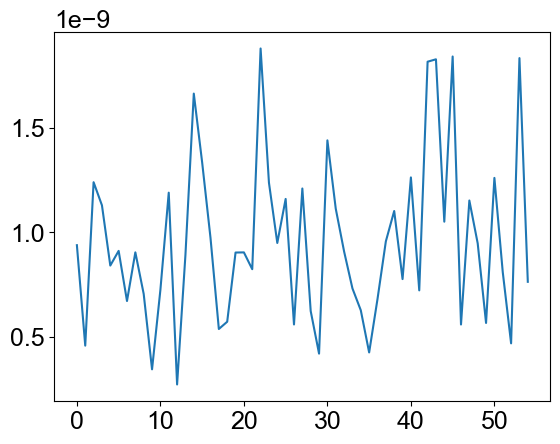

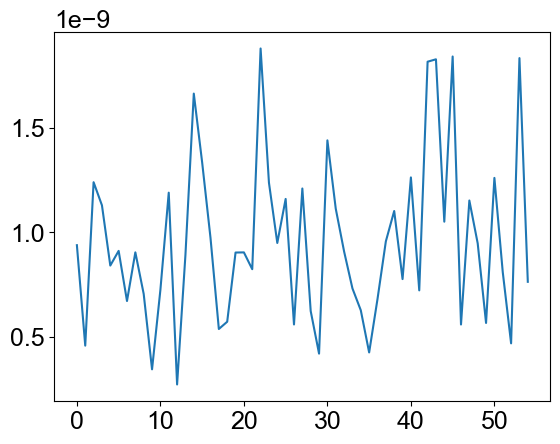

(55, 1)


In [258]:
plt.plot(posterior_alpha_outzone)
plt.show()

plt.plot(out_zone_alpha)
plt.show()

print(out_zone_alpha.shape)

In [262]:
# Compile alpha and pproba into one dataframe for GLM
DF_out = pd.DataFrame()
for sub in subs:
    in_zone_pproba = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_in-zone_relevant_trialwise_probs.csv', header=None)
    in_zone_alpha = pd.read_csv(f'/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/post_alpha_inzone_{sub}.csv', header=None)
    # print(in_zone_alpha.shape)
    in_zone_DF = pd.concat([in_zone_pproba, in_zone_alpha], axis=1)
    in_zone_DF.columns = ['decoding', 'alpha']
    in_zone_DF['zone'] = 'in'
    in_zone_DF['sub'] = sub

    DF_out = pd.concat([DF_out, in_zone_DF], axis=0)

    out_zone_pproba = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/' + sub + '_out-zone_relevant_trialwise_probs.csv', header=None)
    out_zone_alpha = pd.read_csv(f'/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/post_alpha_outzone_{sub}.csv', header=None)
    print(out_zone_alpha.shape)
    print(out_zone_pproba.shape)
    out_zone_DF = pd.concat([out_zone_pproba, out_zone_alpha], axis=1)
    out_zone_DF.columns = ['decoding', 'alpha']
    out_zone_DF['zone'] = 'out'
    out_zone_DF['sub'] = sub

    # in_zone_DF = pd.DataFrame({'decoding':[np.array(in_zone_pproba)], 'alpha':[np.array(in_zone_alpha)]})
    DF_out = pd.concat([DF_out, out_zone_DF], axis=0)

    # print(DF_out.shape)
    # print(in_zone_DF)
    # print(in_zone_pproba)

DF_out.to_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/image_decoding/DF_alpha_decoding_GLM.csv', header=True, index=False)

(54, 1)
(54, 1)
(33, 1)
(33, 1)
(45, 1)
(45, 1)
(33, 1)
(33, 1)
(45, 1)
(45, 1)
(19, 1)
(19, 1)
(32, 1)
(32, 1)
(71, 1)
(71, 1)
(86, 1)
(86, 1)
(57, 1)
(57, 1)
(60, 1)
(60, 1)
(31, 1)
(31, 1)
(12, 1)
(12, 1)
(19, 1)
(19, 1)
(73, 1)
(73, 1)
(85, 1)
(85, 1)
(50, 1)
(50, 1)
(35, 1)
(35, 1)
(54, 1)
(54, 1)
(63, 1)
(63, 1)
(44, 1)
(44, 1)
(38, 1)
(38, 1)
(57, 1)
(57, 1)
(24, 1)
(24, 1)
(55, 1)
(55, 1)


In [253]:
out_zone_DF

,decoding,alpha,zone
0,0.507530,9.378450e-10,out
1,0.538159,4.566316e-10,out
2,0.539883,1.239605e-09,out
3,0.498306,1.128921e-09,out
4,0.515958,8.402388e-10,out
...,...,...,...
122,0.464363,NaN,out
123,0.480650,NaN,out
124,0.535388,NaN,out
125,0.584743,NaN,out


In [245]:
np.array(in_zone_pproba)

array([[0.50753044],
       [0.53815939],
       [0.53988266],
       [0.49830552],
       [0.51595752],
       [0.59754434],
       [0.41249597],
       [0.51544545],
       [0.53091545],
       [0.549314  ],
       [0.53833978],
       [0.48595624],
       [0.54536129],
       [0.5386114 ],
       [0.54194564],
       [0.60039602],
       [0.41827008],
       [0.58114049],
       [0.55056007],
       [0.52238593],
       [0.44714825],
       [0.47467671],
       [0.49176044],
       [0.45341259],
       [0.41482472],
       [0.43854178],
       [0.54508133],
       [0.58090416],
       [0.49091765],
       [0.47747654],
       [0.53999133],
       [0.554576  ],
       [0.58144608],
       [0.45071813],
       [0.51930982],
       [0.52543252],
       [0.52462971],
       [0.5757383 ],
       [0.51563347],
       [0.53356671],
       [0.45303699],
       [0.65938146],
       [0.59678124],
       [0.44931441],
       [0.55314996],
       [0.43774037],
       [0.45301214],
       [0.560

In [241]:
in_zone_DF

,decoding,alpha
0,0 0 0.507530 1 0.538159 2 ...,0 0 3.926870e-10 1 6.980...


In [230]:
posterior_alpha_inzone.shape

(185,)

In [218]:
OP_index

[14, 19, 13, 16, 18, 17]

In [219]:
power_inzone[:,:, alpha_indices,:].shape


(185, 33, 5, 190)

In [206]:
OP_diff

array([[-2.25447759e-11, -2.27826122e-11, -2.40684771e-11, ...,
        -1.33377209e-10, -1.59232638e-10, -1.82764985e-10],
       [-3.08832538e-11, -3.20335394e-11, -3.38178998e-11, ...,
        -9.14192793e-11, -1.16139256e-10, -1.38416934e-10],
       [-3.78861319e-11, -3.99181231e-11, -4.22480057e-11, ...,
        -6.51928594e-11, -8.67429753e-11, -1.05860790e-10],
       ...,
       [-8.55155992e-12, -9.09497301e-12, -9.54172536e-12, ...,
        -5.48555829e-12, -5.26150616e-12, -4.98618847e-12],
       [-6.91603160e-12, -7.39928440e-12, -7.82160304e-12, ...,
        -4.65377583e-12, -4.42877966e-12, -4.16860571e-12],
       [-5.20883635e-12, -5.58802275e-12, -5.93031220e-12, ...,
        -3.27841363e-12, -3.14006909e-12, -2.97708523e-12]])

In [43]:
# all_channels = cacs_montage.ch_names
# # all_channels.remove('GND')
# print(cacs_montage.ch_names)

sub_chan = epochs.pick(picks='eeg').ch_names
print(sub_chan)
missing_channels = list(set(all_channels) - set(sub_chan))
ch_types = ['eeg'] * len(missing_channels)
print(missing_channels)

if missing_channels:
    missing_data = np.full((len(epochs), len(missing_channels), len(epochs.times)), np.nan)
    info = mne.create_info(ch_names=missing_channels, sfreq=epochs.info['sfreq'], ch_types=ch_types)
    raw_missing = mne.EpochsArray(missing_data, info)

    epochs.add_channels([raw_missing], force_update_info=True)

['Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'Pz', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'P3', 'Fp2', 'TP10', 'Fp1', 'TP9']
[]


In [33]:
# x_data[:,19,:]

x_data_new = epochs.get_data(picks='eeg')


In [36]:
x_data_new[:,19,:]

array([[ 3.03911584e-06,  7.79049863e-06,  9.32021655e-06, ...,
         3.76926628e-06,  7.23569241e-07, -4.14115848e-06],
       [-1.17460460e-05, -1.23217210e-05, -4.49639450e-06, ...,
        -5.52006191e-06, -9.47559088e-06, -8.74436302e-07],
       [ 1.20064745e-05,  9.27839513e-06,  5.29185224e-06, ...,
         1.31042371e-06, -5.96497653e-06, -8.08595741e-06],
       ...,
       [-3.94221305e-06, -8.32740713e-06, -8.07826772e-06, ...,
         2.20796487e-05,  2.57981178e-05,  2.23285280e-05],
       [ 7.96248810e-06, -1.40291447e-06,  1.76757154e-06, ...,
         1.14998629e-05,  1.43061275e-05,  1.52934817e-05],
       [-6.70454762e-06, -5.21412769e-06, -1.63700782e-06, ...,
        -1.94571918e-05, -1.73648519e-05, -7.19842527e-06]])

In [215]:
def calculate_BF_morlet(DF, chance):

    # DF shape:
    # frequencies x timepoints x subjects

    bf_matrix = []

    n_freqs = DF.shape[0]
    n_times = DF.shape[1]

    for f in range(n_freqs):

        freq_bfs = []

        for t in range(n_times):

            # subjects vector at this freq/timepoint
            x = DF[f, t, :] - chance

            # convert directly to R vector
            with localconverter(ro.default_converter + numpy2ri.converter):
                r_x = ro.conversion.py2rpy(x)

            # try:
            results = bf_package.ttestBF(
                x=r_x,
                mu=0,
                rscale='medium'
            )

            bf = np.asarray(r['as.vector'](results))[0]

            freq_bfs.append(bf)

            # except:
            #     freq_bfs.append(np.nan)

        bf_matrix.append(freq_bfs)
        # print(bf_matrix.shape)

    return np.array(bf_matrix)

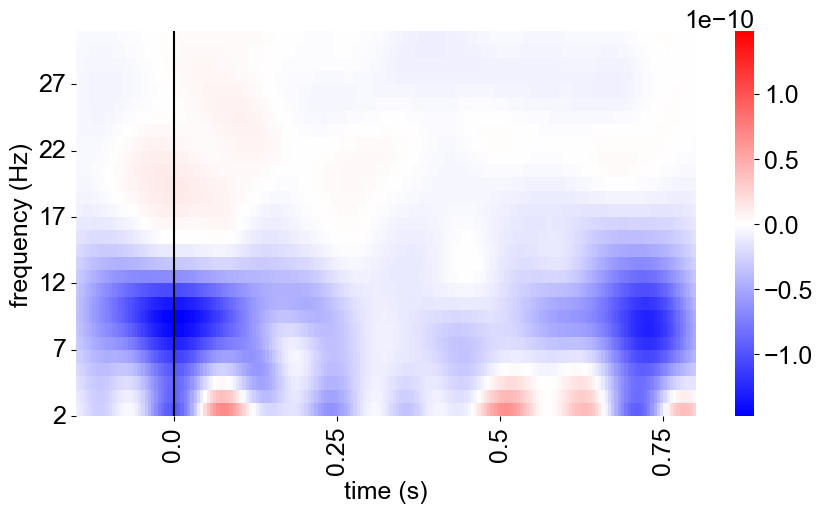

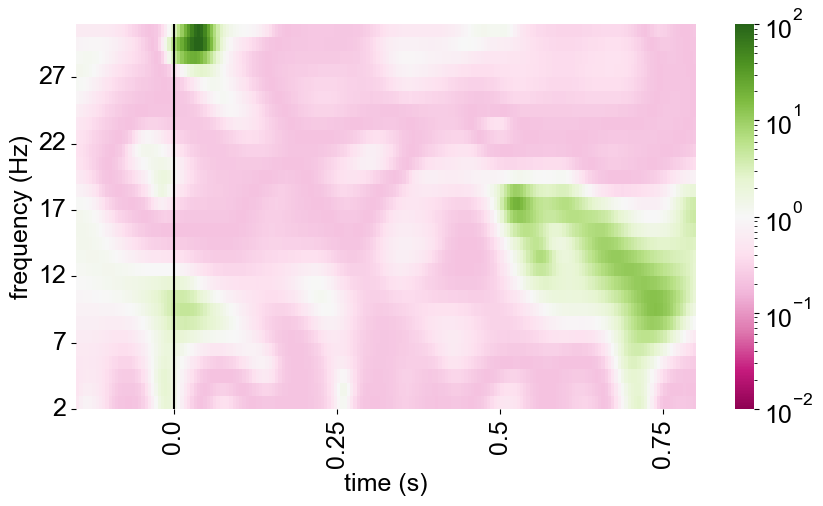

In [268]:
freqs = np.arange(2, 31, 1)#np.logspace(*np.log10([1, 35]), num=8)
from matplotlib.colors import LogNorm

x_positions = np.arange(30, len(epochs.times), 50)
y_positions = np.arange(0, len(freqs), 5)

Fz_diff_DF = []
for sub in subs:
    df = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/OP_difference_{sub}.csv', header=None)
    Fz_diff_DF.append(df)
stacked = np.stack(Fz_diff_DF, axis=2)
mean_stacked = np.mean(stacked, axis=2)

# fig, ax=plt.subplot(figuresize=(10, 20))
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(mean_stacked, center=0, vmin=(-1*np.max(np.abs(mean_stacked))), vmax=(np.max(np.abs(mean_stacked))), cmap='bwr')
plt.xticks(x_positions, epochs.times[x_positions])
ax.set_xlabel('time (s)', fontsize=font_sz)
plt.yticks(y_positions, freqs[y_positions])
ax.set_ylabel('frequency (Hz)', fontsize=font_sz)
plt.axvline(np.where(epochs.times==0), color='k')
ax.invert_yaxis()  # Reverses y-axis (Bottom to Top becomes Top to Bottom)
plt.savefig(figdir + 'time-freq_decomp_OP.png', bbox_inches='tight')

bf_tempgen_image = calculate_BF_morlet(stacked, 0)
vmin = 0.01
vmax = 100.0

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(bf_tempgen_image, norm=LogNorm(vmin=vmin, vmax=vmax), cmap='PiYG')
plt.xticks(x_positions, epochs.times[x_positions])
ax.set_xlabel('time (s)', fontsize=font_sz)

plt.yticks(y_positions, freqs[y_positions])
ax.set_ylabel('frequency (Hz)', fontsize=font_sz)
plt.axvline(np.where(epochs.times==0), color='k')
ax.invert_yaxis()  # Reverses y-axis (Bottom to Top becomes Top to Bottom)
plt.savefig(figdir + 'time-freq_decomp_OP_BF.png', bbox_inches='tight')


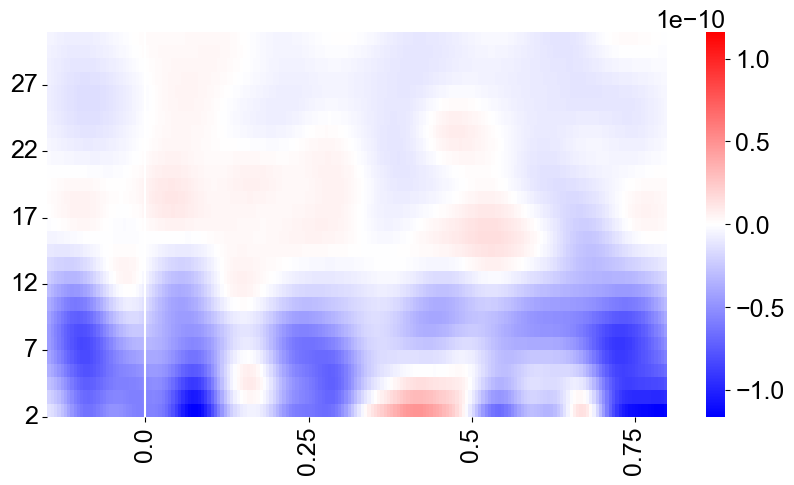

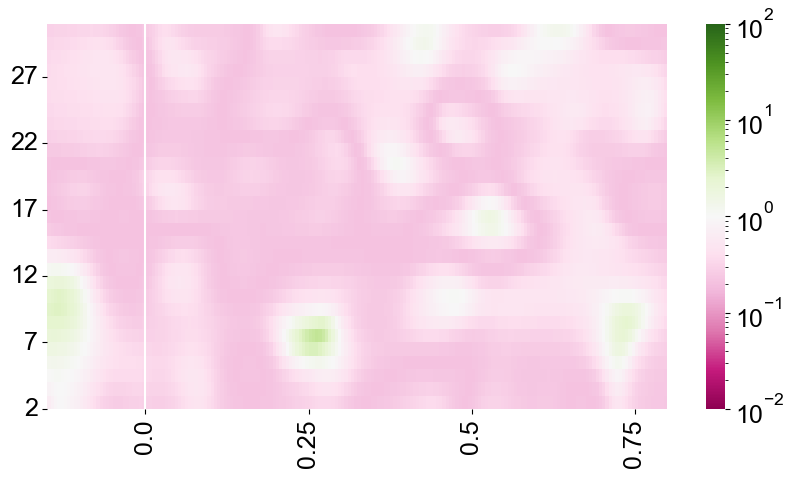

In [235]:

Fz_diff_DF = []
for sub in subs:
    df = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/F_difference_{sub}.csv', header=None)
    Fz_diff_DF.append(df)
stacked = np.stack(Fz_diff_DF, axis=2)
mean_stacked = np.mean(stacked, axis=2)

# fig, ax=plt.subplot(figuresize=(10, 20))
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(mean_stacked, center=0, vmin=(-1*np.max(np.abs(mean_stacked))), vmax=(np.max(np.abs(mean_stacked))), cmap='bwr')
plt.xticks(x_positions, epochs.times[x_positions])
plt.yticks(y_positions, freqs[y_positions])
plt.axvline(np.where(epochs.times==0), color='white')
ax.invert_yaxis()  # Reverses y-axis (Bottom to Top becomes Top to Bottom)


bf_tempgen_image = calculate_BF_morlet(stacked, 0)
vmin = 0.01
vmax = 100.0

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(bf_tempgen_image, norm=LogNorm(vmin=vmin, vmax=vmax), cmap='PiYG')
plt.xticks(x_positions, epochs.times[x_positions])
plt.yticks(y_positions, freqs[y_positions])
plt.axvline(np.where(epochs.times==0), color='white')
ax.invert_yaxis()  # Reverses y-axis (Bottom to Top becomes Top to Bottom)

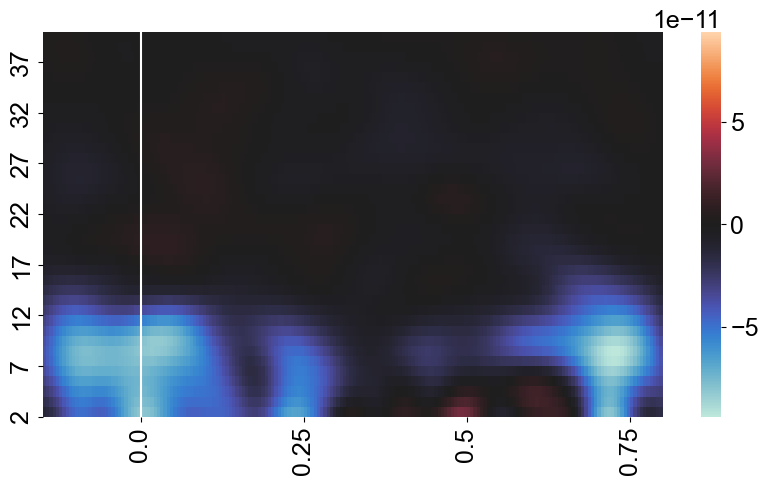

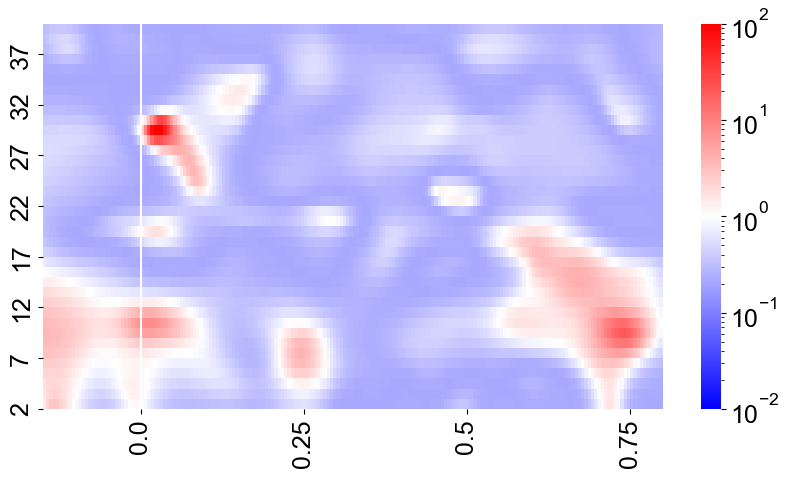

In [219]:
Fz_diff_DF = []
for sub in subs:
    df = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/wholebrain_difference_{sub}.csv', header=None)
    Fz_diff_DF.append(df)
stacked = np.stack(Fz_diff_DF, axis=2)
mean_stacked = np.mean(stacked, axis=2)

# fig, ax=plt.subplot(figuresize=(10, 20))
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(mean_stacked, center=0, vmin=(-1*np.max(np.abs(mean_stacked))), vmax=(np.max(np.abs(mean_stacked))))
plt.xticks(x_positions, epochs.times[x_positions])
plt.yticks(y_positions, freqs[y_positions])
plt.axvline(np.where(epochs.times==0), color='white')
ax.invert_yaxis()  # Reverses y-axis (Bottom to Top becomes Top to Bottom)


bf_tempgen_image = calculate_BF_morlet(stacked, 0)
vmin = 0.01
vmax = 100.0

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(bf_tempgen_image, norm=LogNorm(vmin=vmin, vmax=vmax), cmap='bwr')
plt.xticks(x_positions, epochs.times[x_positions])
plt.yticks(y_positions, freqs[y_positions])
plt.axvline(np.where(epochs.times==0), color='white')
ax.invert_yaxis()  # Reverses y-axis (Bottom to Top becomes Top to Bottom)

In [143]:
stacked.shape

(38, 190, 25)

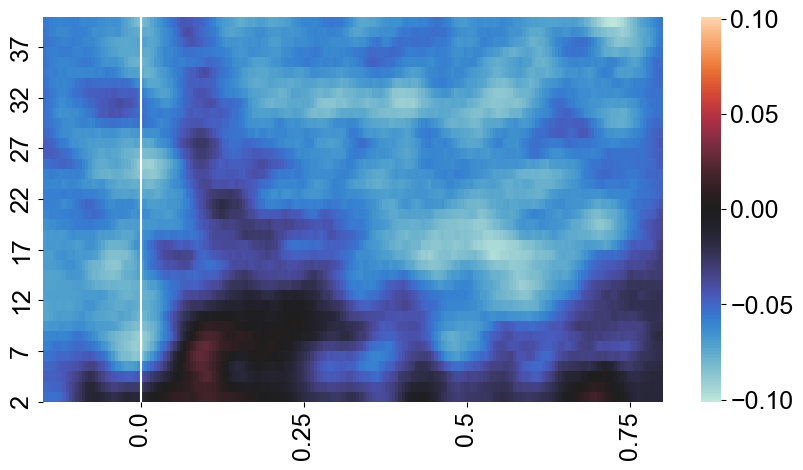

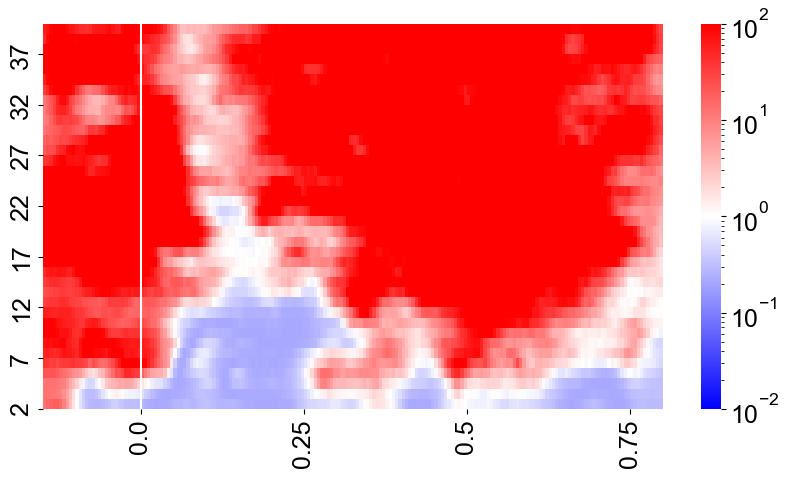

In [220]:

Fz_diff_DF = []
for sub in subs:
    df = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/P_ITC_difference_{sub}.csv', header=None)
    Fz_diff_DF.append(df)
stacked = np.stack(Fz_diff_DF, axis=2)
mean_stacked = np.mean(stacked, axis=2)

# fig, ax=plt.subplot(figuresize=(10, 20))
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(mean_stacked, center=0, vmin=(-1*np.max(np.abs(mean_stacked))), vmax=(np.max(np.abs(mean_stacked))))
plt.xticks(x_positions, epochs.times[x_positions])
plt.yticks(y_positions, freqs[y_positions])
plt.axvline(np.where(epochs.times==0), color='white')
ax.invert_yaxis()  # Reverses y-axis (Bottom to Top becomes Top to Bottom)


bf_tempgen_image = calculate_BF_morlet(stacked, 0)
vmin = 0.01
vmax = 100.0

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(bf_tempgen_image, norm=LogNorm(vmin=vmin, vmax=vmax), cmap='bwr')
plt.xticks(x_positions, epochs.times[x_positions])
plt.yticks(y_positions, freqs[y_positions])
plt.axvline(np.where(epochs.times==0), color='white')
ax.invert_yaxis()  # Reverses y-axis (Bottom to Top becomes Top to Bottom)

In [14]:

def make_ERP_plot(plot_dict):


    # DF = pd.DataFrame({plot_dict['bar1_label']: plot_dict['bar1'], plot_dict['bar2_label']: plot_dict['bar2']})
    # DF_long = pd.melt(DF)
    # print(pg.ttest(plot_dict['bar1'], plot_dict['bar2'], paired=True))

    fig = plt.figure(figsize=(8, 4))
    gs = fig.add_gridspec(
        nrows=2,
        ncols=1,
        width_ratios=[3],
        height_ratios=[3, 1],
        wspace=0.1,
        hspace=0.2
    )

    # Left column
    ax_dec = fig.add_subplot(gs[0, 0])
    ax_bf = fig.add_subplot(gs[1, 0])

    # Right side of decoding plot
    # ax_in_irrel = fig.add_subplot(gs[0, 1], sharey=ax_dec)
    # ax_out_irrel = fig.add_subplot(gs[0, 2], sharey=ax_dec)


    # fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), gridspec_kw={'wspace': 0.4, 'hspace': 0.4, 'height_ratios': [3, 1]})
    ax_dec.plot(plot_dict['x_axis'], plot_dict['tc1'], plot_dict['tc1_color'], linestyle='-',label=plot_dict['tc1_label'])
    ax_dec.fill_between(plot_dict['x_axis'], plot_dict['tc1'] - plot_dict['tc1_SE'], plot_dict['tc1'] + plot_dict['tc1_SE'], color=plot_dict['tc1_color'], alpha=0.3)
    ax_dec.plot(plot_dict['x_axis'], plot_dict['tc2'], plot_dict['tc2_color'], linestyle=plot_dict['tc2_linestyle'],label=plot_dict['tc2_label'])
    ax_dec.fill_between(plot_dict['x_axis'], plot_dict['tc2'] - plot_dict['tc2_SE'], plot_dict['tc2'] + plot_dict['tc2_SE'], color=plot_dict['tc2_color'], alpha=0.3)
    ax_dec.set_ylim(-0.00001, 0.00001)
    ax_dec.set_yticks([-0.000005, 0, 0.000005])
    ax_dec.yaxis.set_inverted(True)


    ax_dec.spines['right'].set_visible(False)
    ax_dec.spines['top'].set_visible(False)
    ax_dec.axhline(0, color="k", linestyle="--")
    ax_dec.set_ylabel(r"Amplitude ($\mu$V) ", fontsize=font_sz)  # Area Under the Curve
    ax_dec.legend(frameon=False, framealpha=0)
    ax_dec.axvline(0.0, color="k", linestyle="-")
    # ax_dec.set_title("Irrelevant image category decoding", fontsize=font_sz)
    ax_dec.set_xticks([])


    # sns.boxplot(x="variable", y="value", data=DF_long, hue="variable", palette = [plot_dict['tc1_color'], plot_dict['tc2_color']], linewidth=2, fliersize=0,  ax=ax_in_irrel)
    # sns.stripplot(x="variable", y="value", data=DF_long, color="black", alpha=0.5, ax=ax_in_irrel)
    # # ax_in_irrel.scatter(0,np.mean(in_irrel_mean), color='white')
    # ax_in_irrel.axhline(0, color="k", linestyle="--")
    # ax_in_irrel.set_xlabel("")
    # ax_in_irrel.set_ylabel("")
    # sns.despine(right=True)

    # ax_out_irrel.tick_params(axis='y', left=False, labelleft=False)

    plot_BF_subplot(plot_dict['x_axis'], plot_dict['BF'], plot_dict['BF_palette'], ax=ax_bf, title=plot_dict['BF_title'], topLim=plot_dict['BF_top'], bottomLim=2, xlabel=True)
    # plt.show()
    plt.savefig(plot_dict['save_name'], bbox_inches='tight')
    plt.show()




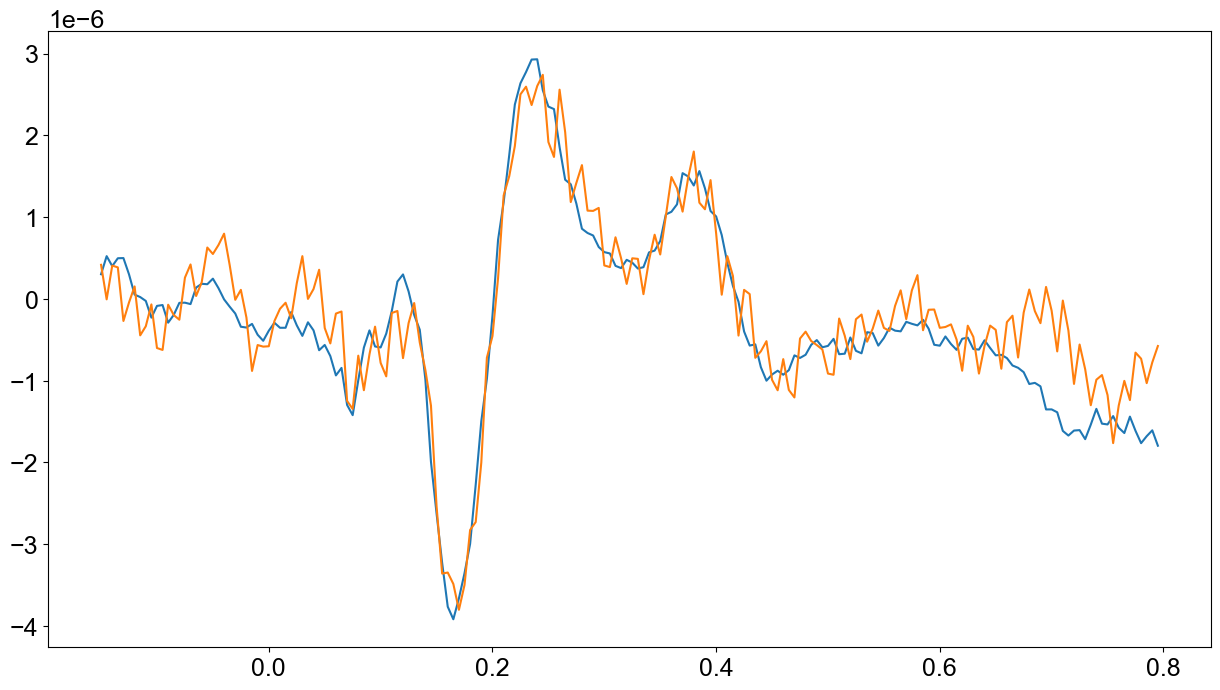

/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


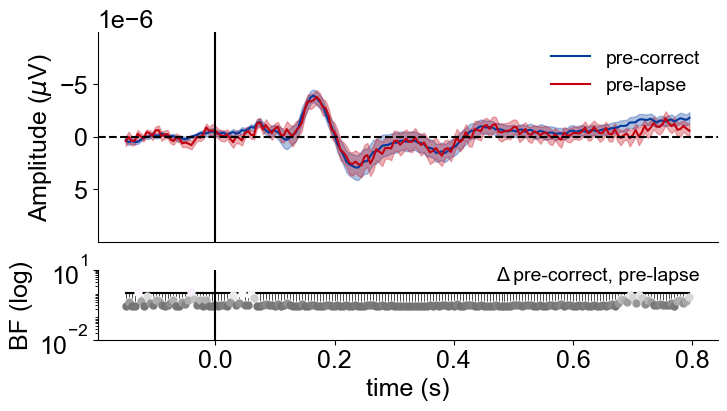

In [19]:
DF_in = []
DF_out = []
for sub in subs:
    df_in = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/P3_inzoneCOCE_{sub}.csv', header=None)
    DF_in.append(df_in)
    df_out = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/P3_outzoneCOCE_{sub}.csv', header=None)
    DF_out.append(df_out)
stacked_in = np.squeeze(np.stack(DF_in, axis=1))
mean_stacked_in = np.squeeze(np.mean(stacked_in, axis=1))
stacked_out = np.squeeze(np.stack(DF_out, axis=1))
mean_stacked_out = np.squeeze(np.mean(stacked_out, axis=1))


SE_in= np.squeeze(stats.sem(stacked_in, axis=1))
SE_out = np.squeeze(stats.sem(stacked_out, axis=1))


bf_diff_inout = calculate_BF(pd.DataFrame(stacked_in).T, pd.DataFrame(stacked_out).T)


fig, ax=plt.subplots(figsize=(15,8))
plt.plot(epochs.times, mean_stacked_in, label='pre-correct')
plt.plot(epochs.times, mean_stacked_out, label='pre-lapse')

plt.show()

plot_dict_rel = {
    'tc1': mean_stacked_in, 
    'tc1_label': "pre-correct",
    'tc2': mean_stacked_out,
    'tc2_label': "pre-lapse",
    'tc1_SE': np.squeeze(SE_in),
    'tc2_SE': np.squeeze(SE_out),
    'tc1_color': blue_color,
    'tc2_color': red_color,
    'tc2_linestyle':'-',
    'BF': bf_diff_inout,
    'BF_palette': purple_palette,
    'BF_title':"\u0394 pre-correct, pre-lapse",
    'BF_top':1,
    'x_axis': epochs.times,
    'save_name':figdir + 'ERP_P3.png'
}

make_ERP_plot(plot_dict_rel)
# print(mean_stacked_in.shape)

In [11]:
mean_stacked_in[0]

3.0175821936006785e-07

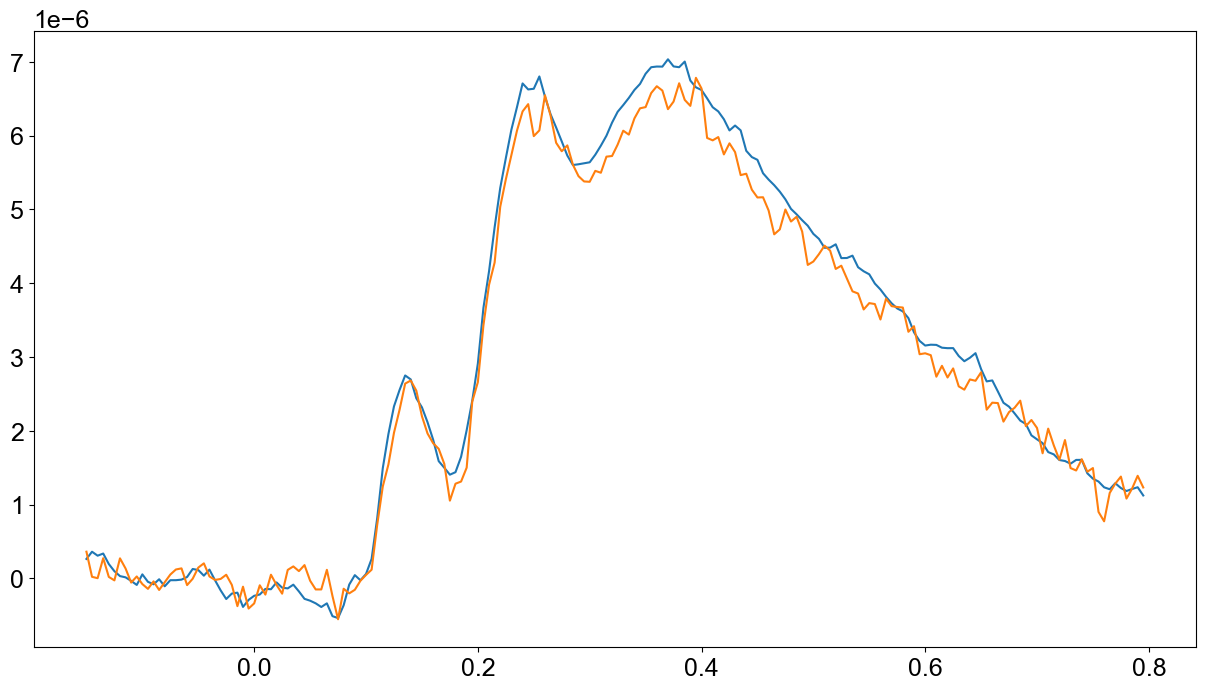

/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


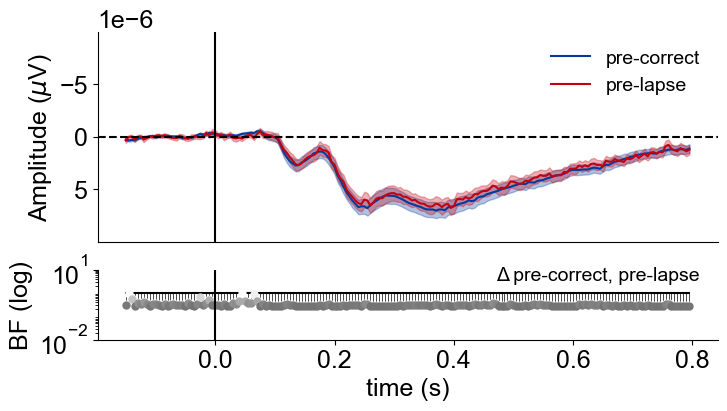

In [20]:
DF_in = []
DF_out = []
for sub in subs:
    df_in = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/N2_inzoneCOCE_{sub}.csv', header=None)
    DF_in.append(df_in)
    df_out = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/N2_outzoneCOCE_{sub}.csv', header=None)
    DF_out.append(df_out)
stacked_in = np.squeeze(np.stack(DF_in, axis=1))
mean_stacked_in = np.squeeze(np.mean(stacked_in, axis=1))
stacked_out = np.squeeze(np.stack(DF_out, axis=1))
mean_stacked_out = np.squeeze(np.mean(stacked_out, axis=1))


SE_in= np.squeeze(stats.sem(stacked_in, axis=1))
SE_out = np.squeeze(stats.sem(stacked_out, axis=1))


bf_diff_inout = calculate_BF(pd.DataFrame(stacked_in).T, pd.DataFrame(stacked_out).T)


fig, ax=plt.subplots(figsize=(15,8))
plt.plot(epochs.times, mean_stacked_in, label='pre-correct')
plt.plot(epochs.times, mean_stacked_out, label='pre-lapse')

plt.show()

plot_dict_rel = {
    'tc1': mean_stacked_in, 
    'tc1_label': "pre-correct",
    'tc2': mean_stacked_out,
    'tc2_label': "pre-lapse",
    'tc1_SE': np.squeeze(SE_in),
    'tc2_SE': np.squeeze(SE_out),
    'tc1_color': blue_color,
    'tc2_color': red_color,
    'tc2_linestyle':'-',
    'BF': bf_diff_inout,
    'BF_palette': purple_palette,
    'BF_title':"\u0394 pre-correct, pre-lapse",
    'BF_top':1,
    'x_axis': epochs.times,
    'save_name':figdir + 'ERP_N2.png'
}

make_ERP_plot(plot_dict_rel)

In [249]:
def calculate_BF_ERPs(DF):

    # DF shape:
    # frequencies x timepoints x subjects

    bf_matrix = []

    n_freqs = DF.shape[0]
    n_times = DF.shape[1]
    # print(n_freqs)

    for f in range(n_freqs):

        freq_bfs = []

        for t in range(n_times):

            # subjects vector at this freq/timepoint
            # print(DF[f, t, :].shape)
            x = DF[f, t, :] 
            # print(x)
            x_clean = x[~np.isnan(x)]
            # print(x_clean)

            # convert directly to R vector
            with localconverter(ro.default_converter + numpy2ri.converter):
                r_x = ro.conversion.py2rpy(x_clean)

            try:
                results = bf_package.ttestBF(
                    x=r_x,
                    mu=0,
                    rscale='medium'
                )

                bf = np.asarray(r['as.vector'](results))[0]

                freq_bfs.append(bf)

            except:
                freq_bfs.append(np.nan)

        bf_matrix.append(freq_bfs)
        # print(bf_matrix.shape)

    return np.array(bf_matrix)

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/3459963394.py:11: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  info.set_montage(cacs_montage)
/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/3459963394.py:20: RuntimeWarning: Mean of empty slice
  mean_stacked_diff = np.nanmean(stacked_diff, axis=2)
  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough observations

  not enough obser

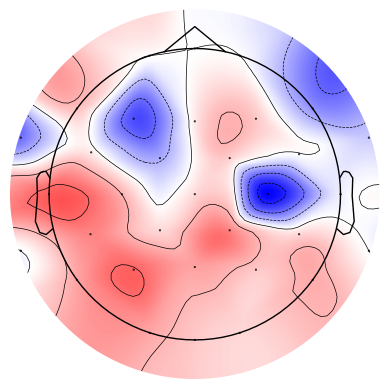

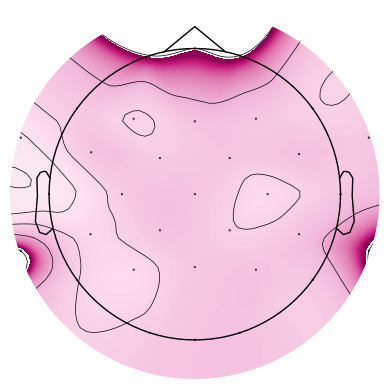

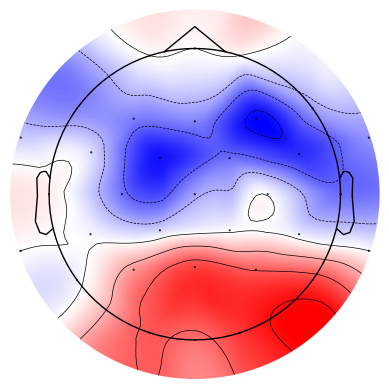

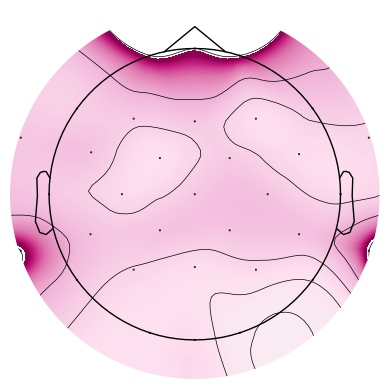

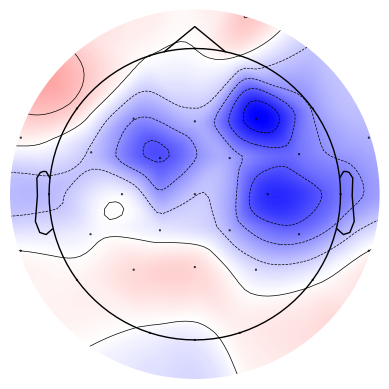

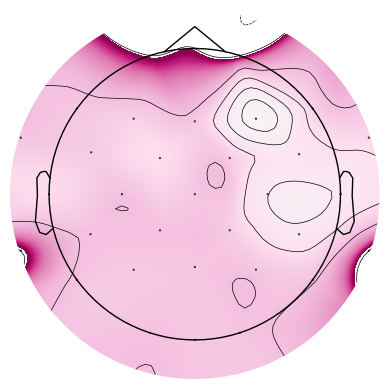

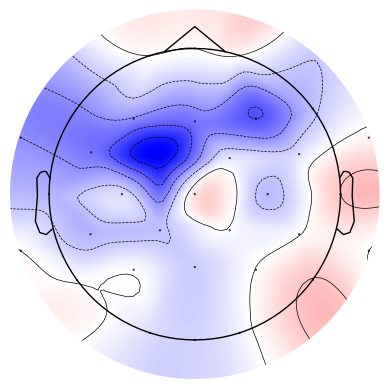

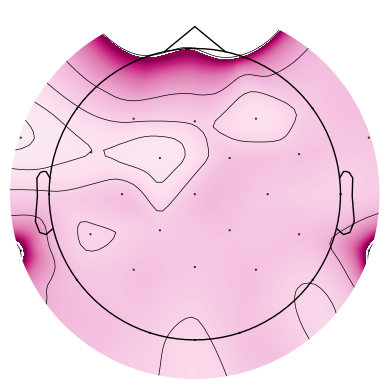

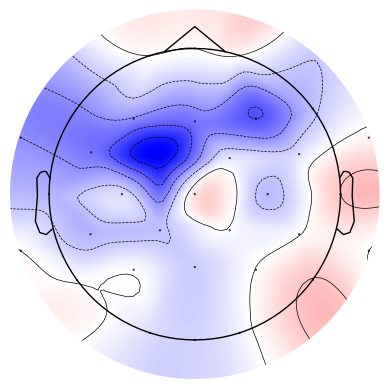

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/3459963394.py:50: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

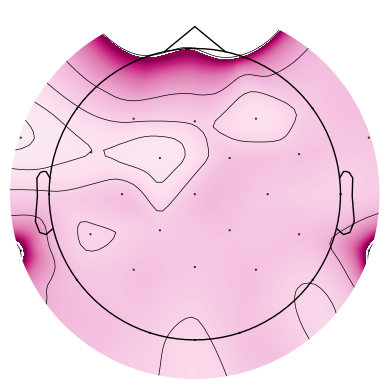

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/3459963394.py:56: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

In [264]:
# montage=mne.channels.make_standard_montage('standard_1020')
# t_in = np.mean(x_test_image_inzone, axis=0)
# t_out = np.mean(x_test_image_outzone, axis=0)
# tt = t_in - t_out
import matplotlib.colors as mcolors

times = [ 0, .205, .4, .6]


info = mne.create_info(ch_names=cacs_montage.ch_names, sfreq=epochs.info['sfreq'], ch_types='eeg')
info.set_montage(cacs_montage)

DF_diff = []
for sub in subs:
    df_diff = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/ERP_in-out_difference_image_{sub}.csv', header=None)
    DF_diff.append(df_diff)
    # df_out = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/image_decoding/N2_outzoneCOCE_{sub}.csv', header=None)
    # DF_out.append(df_out)
stacked_diff = np.squeeze(np.stack(DF_diff, axis=2))
mean_stacked_diff = np.nanmean(stacked_diff, axis=2)
bf_tempgen_image = calculate_BF_ERPs(stacked_diff)

diff_clean = np.nan_to_num(mean_stacked_diff, nan=0)
bf_clean = np.nan_to_num(bf_tempgen_image, nan=0.0)

# 

vmin = 0.01
vmax = 100.0

norm=mcolors.LogNorm(vmin=vmin, vmax=vmax)


for t in times:
    fig, ax = plt.subplots()
    # im, _ = mne.viz.plot_topomap(np.nan_to_num(np.squeeze(mean_stacked_diff[:,epochs.times==t]), nan=0), info, cmap='bwr', axes=ax, show=True, extrapolate='head')
    im, _ = mne.viz.plot_topomap(np.squeeze(diff_clean[:,epochs.times==t]), info, cmap='bwr', axes=ax, show=True, extrapolate='head')

    # plt.colorbar(im, ax=ax, shrink=0.6)
    fig.savefig(figdir + f'topo_plot_time{t}.png')


    fig, ax = plt.subplots()
    im, _ = mne.viz.plot_topomap(np.squeeze(bf_clean[:,epochs.times==t]), info, cmap='PiYG', axes=ax, cnorm=norm, show=True)
    # plt.colorbar(im, ax=ax, shrink=0.6)
    fig.savefig(figdir + f'BF_topo_plot_time{t}.png')

fig, ax = plt.subplots()
im, _ = mne.viz.plot_topomap(np.squeeze(diff_clean[:,epochs.times==t]), info, cmap='bwr', axes=ax, show=True, extrapolate='head')
plt.colorbar(im, ax=ax, shrink=0.6)
fig.savefig(figdir + f'topo_plot_colorbar.png')


fig, ax = plt.subplots()
im, _ = mne.viz.plot_topomap(np.squeeze(bf_clean[:,epochs.times==t]), info, cmap='PiYG', axes=ax, cnorm=norm, show=True)
plt.colorbar(im, ax=ax, shrink=0.6)
fig.savefig(figdir + f'BF_topo_plot_colorbar.png')


In [265]:
diff_clean[:,epochs.times==t]

array([[ 0.00000000e+00],
       [ 0.00000000e+00],
       [-6.20194780e-07],
       [-5.19005116e-07],
       [-5.22263361e-07],
       [-4.99438096e-07],
       [-6.14648865e-07],
       [-1.13366362e-06],
       [-1.63698379e-07],
       [-3.33413511e-07],
       [ 0.00000000e+00],
       [-3.25936636e-07],
       [-2.80631890e-07],
       [-2.18301265e-07],
       [-2.43493199e-08],
       [-1.75120587e-08],
       [-1.50295738e-07],
       [-1.96478098e-07],
       [-6.65799223e-08],
       [ 4.69368831e-09],
       [ 2.56943520e-07],
       [ 0.00000000e+00],
       [-8.66548438e-09],
       [-1.30750962e-08],
       [ 1.22861856e-07],
       [-3.06317800e-07],
       [ 2.49954864e-07],
       [ 5.55671876e-08],
       [-1.41063663e-07],
       [-1.13289290e-07],
       [-7.56274029e-07],
       [-2.91580165e-07],
       [ 0.00000000e+00]])

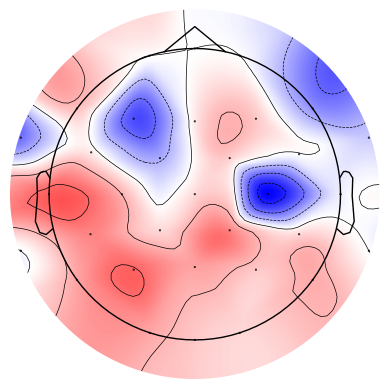

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/195894478.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

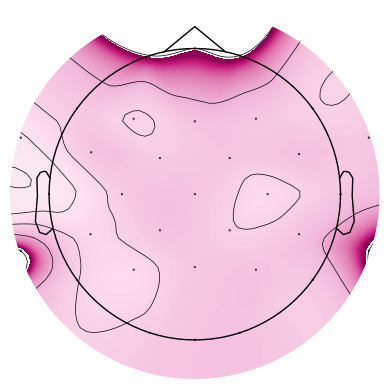

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/195894478.py:10: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

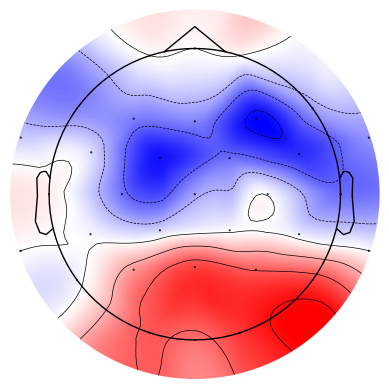

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/195894478.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

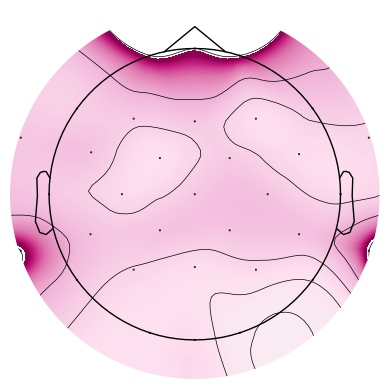

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/195894478.py:10: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

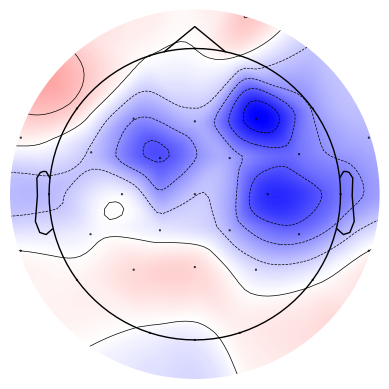

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/195894478.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

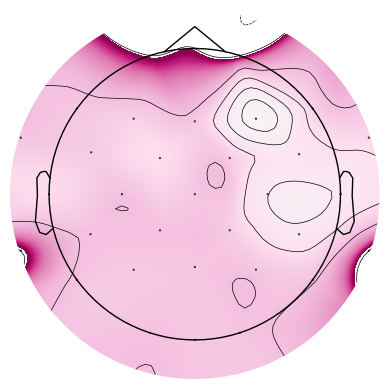

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/195894478.py:10: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

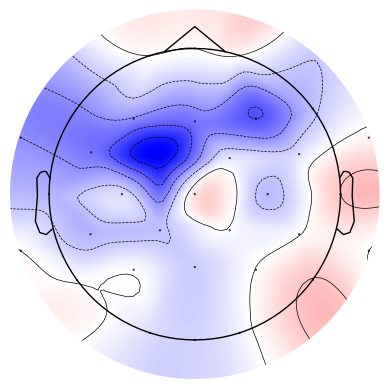

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/195894478.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

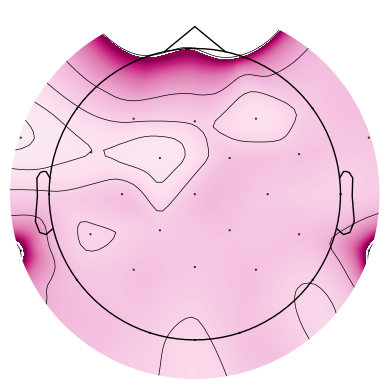

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/195894478.py:10: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

In [ ]:

for t in times:
    fig, ax = plt.subplots()
    im, _ = mne.viz.plot_topomap(np.nan_to_num(np.squeeze(mean_stacked_diff[:,epochs.times==t]), nan=0), info, cmap='bwr', axes=ax, show=True, extrapolate='head')
    # plt.colorbar(im, ax=ax, shrink=0.6)
    fig.savefig(figdir + f'topo_plot_time{t}.png')


    fig, ax = plt.subplots()
    im, _ = mne.viz.plot_topomap(np.squeeze(bf_clean[:,epochs.times==t]), info, cmap='PiYG', axes=ax, cnorm=norm, show=True)
    # plt.colorbar(im, ax=ax, shrink=0.6)
    fig.savefig(figdir + f'BF_topo_plot_time{t}.png')



# mne.viz.plot_topomap(tt[0,:], pos=cacs_montage, names=epochs.info['ch_names'])
# epochs.plot_sensors(ch_type='eeg', show_names=True)


In [255]:
np.nan_to_num(np.squeeze(mean_stacked_diff[:,epochs.times==0]), nan=0)

array([ 0.00000000e+00,  0.00000000e+00,  4.56458826e-08, -3.63672801e-07,
        1.17167172e-07, -2.76203756e-07,  3.58856172e-08, -1.66737945e-07,
        1.48814125e-07,  3.30797053e-07,  0.00000000e+00,  2.47237855e-07,
        7.51778545e-08,  1.90017392e-07,  3.07904310e-07,  1.88705936e-07,
        1.82285833e-07,  1.11189666e-07,  8.22971094e-08,  1.16023806e-07,
        1.67384485e-07,  0.00000000e+00,  7.53388872e-08,  2.47741518e-07,
        7.80684851e-08, -5.14759181e-07, -3.74219165e-08, -1.05022893e-07,
       -2.67177582e-09,  9.63984921e-08,  1.14386648e-07, -2.08098806e-07,
        0.00000000e+00])

In [247]:
mean_stacked_diff

array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [-5.97739673e-07, -4.27695815e-07, -5.11993958e-07, ...,
        -1.77230056e-07, -1.60940530e-07, -3.08651208e-07],
       ...,
       [-9.65863118e-07, -5.41267348e-07, -6.35773754e-07, ...,
        -8.27591076e-07, -5.50613984e-07, -3.05953926e-07],
       [-6.39624564e-07, -1.65487597e-07, -3.65579238e-07, ...,
        -1.97785493e-07,  2.13006449e-07,  1.89812234e-07],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan]])

In [214]:
bf_tempgen_image.shape
mean_stacked_diff.shape

(33, 190)

In [207]:
mean_stacked_diff[:,0]

array([-5.97739673e-07, -9.24095159e-07, -6.30877845e-07, -5.83323237e-07,
       -7.69634744e-07, -8.28871264e-07, -6.12809043e-07, -4.24153508e-07,
       -5.63996494e-07, -4.09944058e-07, -2.81069951e-07, -5.86793314e-07,
       -2.36802892e-07,  1.27125427e-07,  2.75757872e-07,  5.65858914e-07,
       -4.60767988e-08, -8.47442295e-08, -3.26859766e-07, -5.04234911e-07,
       -5.83218023e-07, -6.65223911e-07, -4.10068233e-07, -1.72482237e-07,
       -2.07687810e-07, -7.07922300e-07, -7.97315575e-07, -1.49814263e-07,
                   nan,             nan,             nan,             nan,
                   nan])

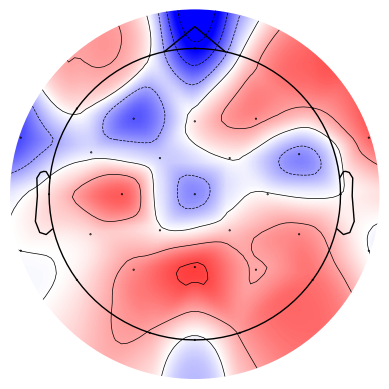

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/547031265.py:5: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

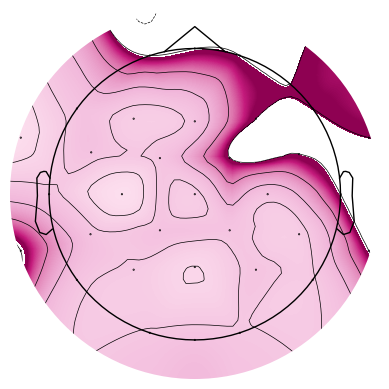

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/547031265.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

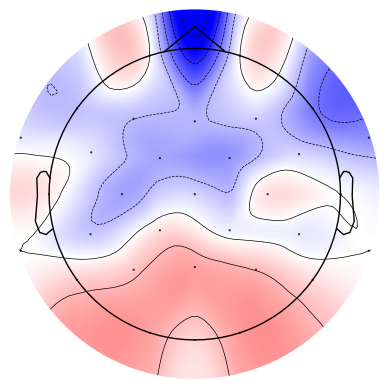

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/547031265.py:5: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

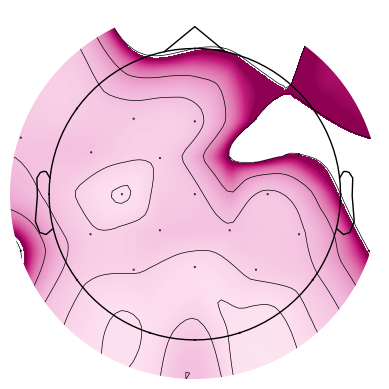

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/547031265.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

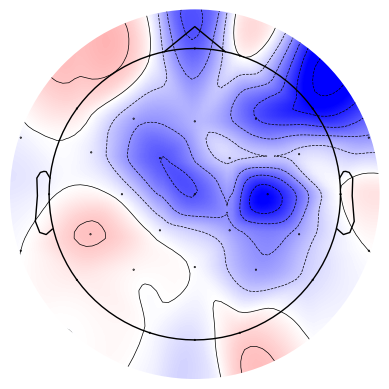

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/547031265.py:5: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

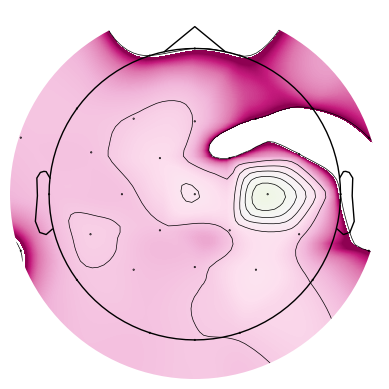

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/547031265.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

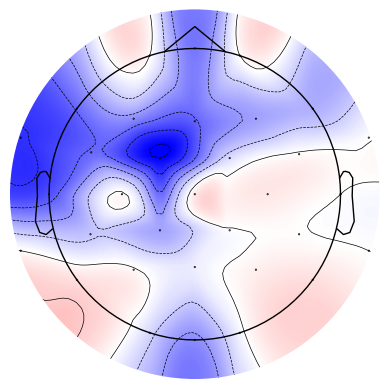

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/547031265.py:5: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

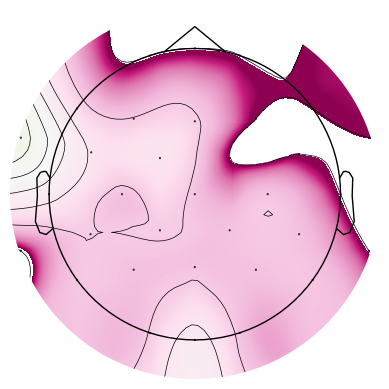

/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_50344/547031265.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, shrink=0.6)


<Figure size 640x480 with 0 Axes>

In [203]:

# log_norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
for t in times:
    fig, ax = plt.subplots()
    im, _ = mne.viz.plot_topomap(np.squeeze(data_clean[:,epochs.times==t]), info, cmap='bwr', axes=ax, show=True)
    plt.colorbar(im, ax=ax, shrink=0.6)
    fig.savefig(figdir + f'topo_plot_time{t}.png')


    fig, ax = plt.subplots()
    im, _ = mne.viz.plot_topomap(np.squeeze(bf_clean[:,epochs.times==t]), info, cmap='PiYG', axes=ax, cnorm=norm, show=True)
    plt.colorbar(im, ax=ax, shrink=0.6)
    fig.savefig(figdir + f'BF_topo_plot_time{t}.png')




In [251]:
data_clean[:,epochs.times==0].shape

(33, 1)